# Team number: 68
# FULL names: 
- Ngoc Bao Han Tran
- Eveline Priscilia Setiawan
- Muhammad Akbar Ibrahim
- Thi Hau Nguyen
# Student ID numbers:
- 48393479
- 48059927
- 48377171
- 48040630

# Answer to Section 1: Clean the dataset  (in this section, insert as many cells as needed) 

In [19]:
# Import required libraries for data handling, visualization, and suppressing warnings
import pandas as pd  # for data manipulation and analysis
import numpy as np  # for numerical operations
import seaborn as sns  # for statistical data visualization
import matplotlib.pyplot as plt  # for creating static, animated, and interactive plots
from pandas import NA  # 'NA' is pandas' scalar for missing values, better for nullable dtypes
from collections import Counter  # Import Counter to count occurrences of values efficiently
from IPython.display import display #  display from IPython for better output in notebooks
import warnings
warnings.filterwarnings('ignore')  # ignore warnings to keep output clean

# Load the CSV files into separate DataFrames
df1 = pd.read_csv('Dataset1.csv', encoding='ISO-8859-1', low_memory=False)  # read first dataset
df2 = pd.read_csv('Dataset2.csv', encoding='ISO-8859-1', low_memory=False)  # read second dataset

# Concatenate the two DataFrames row-wise into one combined DataFrame
df = pd.concat([df1, df2], ignore_index=True)

# Drop any rows where all values are NaN (completely empty rows)
df.dropna(how='all', inplace=True)


In [20]:
df.head()  # Display the first 5 rows of the DataFrame to preview its structure and content


,accounting_date,company_code,customer_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,item_type,bonus_group_code,...,value_sales,value_cost,value_quantity,value_price_adjustment,currency,item_source_class,invoice_number,line_number,customer_order_number,dss_update_time
0,NaN,101.0,411800601,NaN,GENIE8WWWBC,LMP,LMP01008,LMP01,NaN,Trade,...,655.20,252.0,252.0,0.0,AUD,NaN,2217887.0,1.0,2865354.0,49:58.7
1,20200216.0,101.0,361000403,NaN,GENIE8WWWBC,LMP,LMP01008,LMP01,NaN,NaN,...,114.84,36.0,36.0,0.0,AUD,NaN,2185745.0,1.0,2833515.0,49:58.7
2,20230509.0,101.0,361000403,300.0,GENIE8WWWBC,LMP,LMP01008,LMP01,NaN,Trade,...,NaN,36.0,36.0,0.0,AUD,NaN,2217807.0,1.0,2864857.0,49:58.7
3,20230518.0,101.0,565540415,500.0,GENIE8WWWBC,LMP,LMP01008,LMP01,NaN,Trade,...,60.30,18.0,18.0,0.0,AUD,NaN,2222758.0,1.0,2869759.0,49:58.7
4,20200109.0,101.0,565540415,500.0,GENIE8WWWBC,LMP,LMP01008,LMP01,NaN,Trade,...,57.42,18.0,18.0,0.0,AUD,NaN,2170374.0,1.0,2819189.0,49:58.7


In [21]:
# Create a summary DataFrame with information about missing data and data types for each column
summary = pd.DataFrame({
    'Non-Null Count': df.notnull().sum(),  # count of non-null (non-missing) values in each column
    'Null Count': df.isnull().sum(),       # count of null (missing) values in each column
    'Dtype': df.dtypes,                    # data type of each column
    'Missing (%)': df.isnull().mean().round(10) * 100  # percentage of missing values per column, rounded to 10 decimals
})

# Reset the index to make the column names a regular column and rename it to 'Column'
summary = summary.reset_index().rename(columns={'index': 'Column'})

# Display the summary DataFrame
summary


,Column,Non-Null Count,Null Count,Dtype,Missing (%)
0,accounting_date,1988374,8,float64,0.000402
1,company_code,1988363,19,float64,0.000956
2,customer_code,1988371,11,object,0.000553
3,customer_district_code,1988373,9,float64,0.000453
4,item_code,1988376,6,object,0.000302
5,business_area_code,1988376,6,object,0.000302
6,item_group_code,1988375,7,object,0.000352
7,item_class_code,1988367,15,object,0.000754
8,item_type,1988296,86,float64,0.004325
9,bonus_group_code,1988366,16,object,0.000805


In [22]:
df.describe(include='all').T  # Generate descriptive statistics for all columns, including non-numeric ones, and transpose the result for better readability


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
accounting_date,1988374.0,NaN,NaN,NaN,20220669.158504,14146.959166,20200102.0,20210408.0,20220627.0,20230918.0,20241231.0
company_code,1988363.0,NaN,NaN,NaN,230.012884,184.312918,100.0,205.0,205.0,205.0,950.0
customer_code,1988371,4487,234750001,61844,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_district_code,1988373.0,NaN,NaN,NaN,381.773017,152.746184,100.0,300.0,400.0,500.0,720.0
item_code,1988376,34472,25550,9265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
business_area_code,1988376,28,LMP,808686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_group_code,1988375,614,999,187247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_class_code,1988367,204,LMP05,200717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_type,1988296.0,NaN,NaN,NaN,5.835427,1.888821,1.0,5.0,7.0,7.0,9.0
bonus_group_code,1988366,2,Trade,1652554,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
cols_to_drop = [
    'item_source_class',  # 100% missing → no usable data, safe to remove
    'dss_update_time',    # Timestamp column with only one unique value → no variability, not useful
    'market_segment',     # Only drop if all rows have the same value → offers no informational gain
]

# Drop the specified columns from the DataFrame
df = df.drop(columns=cols_to_drop)


In [24]:
# Define the list of columns to inspect for unique values
columns_to_check = [
    'accounting_date',
    'company_code',
    'customer_code',
    'customer_district_code',
    'item_code',
    'business_area_code',
    'item_group_code',
    'item_class_code',
    'item_type',
    'bonus_group_code',
    'environment_group_code',
    'technology_group_code',
    'commission_group_code',
    'reporting_classification',
    'light_source',
    'warehouse_code',
    'abc_class_code',
    'abc_class_volume',
    'business_chain_l1_code',
    'business_chain_l1_name',
    'contact_method_code',
    'salesperson_code',
    'order_type_code',
    'market_segment',
    'value_sales',
    'value_cost',
    'value_quantity',
    'value_price_adjustment',
    'currency',
    'invoice_number',
    'line_number',
    'customer_order_number',
    'dss_update_time'
]

# Loop through each column in the list and check if it exists in the DataFrame
for col in columns_to_check:
    if col in df.columns:
        nunique = df[col].nunique(dropna=False)  # Count of unique values, including NaNs
        unique_vals = df[col].unique()           # Array of unique values (including NaN)
        
        # Print the count and list of unique values for inspection
        print(f"\nUnique values in '{col}' ({nunique} total):")
        print(unique_vals)
        print('-' * 40)  # Print a separator line of 40 dashes for readability



Unique values in 'accounting_date' (1631 total):
[      nan 20200216. 20230509. ... 20231222. 20211222. 20221222.]
----------------------------------------

Unique values in 'company_code' (11 total):
[101. 100. 140. 205. 170. 220. 950. 240. 510.  nan 120.]
----------------------------------------

Unique values in 'customer_code' (4488 total):
['411800601' '361000403' '565540415' ... 'ZI2000017 ' 'Z85020601 '
 '434790100']
----------------------------------------

Unique values in 'customer_district_code' (18 total):
[ nan 300. 500. 310. 400. 200. 410. 210. 720. 710. 600. 510. 530. 535.
 540. 520. 545. 100.]
----------------------------------------

Unique values in 'item_code' (34473 total):
['GENIE8WWWBC                   ' 'GENIE11WWWES                  '
 'GENIE18WCDLES                 ' ... 'DT3132221822ADW               '
 'DT34675139E                   ' '0.90811.00-910                ']
----------------------------------------

Unique values in 'business_area_code' (29 total)

## Convert Variables

In [26]:
# Step 1: Drop rows where 'accounting_date' is missing (NaN)
df = df[df['accounting_date'].notna()]

# Step 2: Convert 'accounting_date' from float to integer, then to string
# This prepares the date for string-based filtering and parsing
df['accounting_date'] = df['accounting_date'].astype(int).astype(str)

# Step 3: Keep only rows where 'accounting_date' matches exactly 8 digits (YYYYMMDD format)
df = df[df['accounting_date'].str.match(r'^\d{8}$')]

# Additional step: Convert the string dates to datetime, coercing errors to NaT (invalid dates)
temp_dates = pd.to_datetime(df['accounting_date'], format='%Y%m%d', errors='coerce')

# Create a mask for valid dates (non-NaT values)
valid_dates_mask = temp_dates.notna()

# Step 4: Apply the mask to keep only rows with valid date formats
df = df[valid_dates_mask]

# Safely convert 'accounting_date' column to datetime dtype
df['accounting_date'] = pd.to_datetime(df['accounting_date'], format='%Y%m%d')

# Step 5: Extract year and month from the datetime column into new columns
df['accounting_year'] = df['accounting_date'].dt.year
df['accounting_month'] = df['accounting_date'].dt.month


In [27]:

# List of columns expected to contain integer-like values that need cleaning
int_columns = [
    'company_code',
    'customer_district_code',
    'item_type',
    'invoice_number',
    'line_number'
]

# Loop through each specified column to clean and standardize values
for col in int_columns:
    df[col] = df[col].apply(
        lambda x: 
            # If value is not missing and is an integer or float that is a whole number, convert to int and then string
            str(int(x)) if pd.notna(x) and isinstance(x, (int, float)) and float(x).is_integer()
            # If value is missing (NaN), assign pandas' NA for consistent missing representation
            else pd.NA if pd.isna(x)
            # Otherwise, convert value to string and strip whitespace
            else str(x).strip()
    )


In [28]:
# Clean 'customer_order_number' by converting to string, stripping whitespace,
# and removing trailing '.0' (common when numeric values are read as floats),
# while preserving missing values as pd.NA
df['customer_order_number'] = df['customer_order_number'].apply(
    lambda x: str(x).strip().replace('.0', '') if pd.notna(x) else pd.NA
)


In [29]:
string_columns = [
    'customer_code', 'item_code', 'business_area_code', 'item_group_code',
    'item_class_code', 'bonus_group_code', 'environment_group_code', 
    'technology_group_code', 'commission_group_code', 'reporting_classification',
    'light_source', 'warehouse_code', 'abc_class_code', 'abc_class_volume',
    'business_chain_l1_code', 'business_chain_l1_name', 'contact_method_code',
    'salesperson_code', 'order_type_code', 'currency', 'customer_order_number',
]

# Loop through each specified string column (if it exists in the DataFrame)
for col in string_columns:
    if col in df.columns:
        df[col] = df[col].apply(
            # Convert value to string, strip whitespace, and convert to uppercase;
            # if value is missing, assign pandas' NA (nullable missing value)
            lambda x: str(x).strip().upper() if pd.notna(x) else NA
        ).astype("string")  # Ensure column uses pandas nullable string dtype for better handling of missing values


In [30]:
# Calculate the percentage of missing values in each row
row_missing_percent = df.isnull().mean(axis=1)

# Filter out rows where more than 50% of the columns are missing
df = df[row_missing_percent <= 0.5]


In [31]:
# Count the total number of missing values in each column
df.isnull().sum()


accounting_date              0
company_code                14
customer_code                5
customer_district_code       2
item_code                    1
business_area_code           0
item_group_code              2
item_class_code              9
item_type                   80
bonus_group_code            10
environment_group_code      23
technology_group_code       12
commission_group_code       16
reporting_classification    14
light_source                 7
warehouse_code               9
abc_class_code              12
abc_class_volume             0
business_chain_l1_code       1
business_chain_l1_name       5
contact_method_code          4
salesperson_code            16
order_type_code             14
value_sales                  2
value_cost                   0
value_quantity               1
value_price_adjustment       1
currency                     0
invoice_number               1
line_number                  2
customer_order_number        1
accounting_year              0
accounti

# Handle Missing Data

### Variable company_code & warehouse_code

In [34]:
# Create a crosstab of 'company_code' vs 'warehouse_code',
# treating NaN values as a separate category (dropna=False)
crosstab = pd.crosstab(df['company_code'], df['warehouse_code'], dropna=False)

# Transpose and display the crosstab for better readability
crosstab.T


company_code,100,101,120,140,170,205,220,240,510,950,NaN
warehouse_code,,,,,,,,,,,
1N0,0,43314,0,0,0,0,0,0,0,0,0
1N1,0,60760,0,0,0,0,0,0,0,0,0
1N2,0,14,0,0,0,0,0,0,0,0,0
1N3,0,9,0,0,0,0,0,0,0,0,0
1Q0,0,27996,0,0,0,0,0,0,0,0,0
1Q1,0,3724,0,0,0,0,0,0,0,0,0
1S0,0,9016,0,0,0,0,0,0,0,0,0
1S1,0,2316,0,0,0,0,0,0,0,0,0
1T0,0,612,0,0,0,0,0,0,0,0,0


In [35]:
# Step 1: Create a mapping from each warehouse_code to the most frequent (mode) company_code
# Only consider rows where 'company_code' is not missing
warehouse_to_company = (
    df[df['company_code'].notna()]
    .groupby('warehouse_code')['company_code']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)  # mode returns the most common value
    .to_dict()
)

# Step 2: Impute missing 'company_code' values by looking up the corresponding 'warehouse_code' in the mapping
# If 'company_code' is missing (NaN), replace it with the mapped value from 'warehouse_code' if available
df['company_code'] = df.apply(
    lambda row: warehouse_to_company.get(row['warehouse_code'], row['company_code']) 
    if pd.isna(row['company_code']) else row['company_code'],
    axis=1
)

# Step 3: Print the count of remaining missing 'company_code' values after imputation
missing = df['company_code'].isna().sum()
print(f" Remaining missing 'company_code' values after warehouse_code mapping: {missing}")


 Remaining missing 'company_code' values after warehouse_code mapping: 0


In [36]:
# Replace missing values in 'warehouse_code' with the string 'UNK' (unknown)
df['warehouse_code'] = df['warehouse_code'].fillna('UNK')


### Variable business_area_code & item_class_code & item_group_code

In [38]:
# Helper function to build a mapping from a prefix of 'from_col' values to the most common 'to_col' value
def build_prefix_mapping(df, from_col, to_col, prefix_len=None, full_match=False):
    # Select rows where both from_col and to_col are not missing
    valid_rows = df[pd.notna(df[from_col]) & pd.notna(df[to_col])].copy()
    
    # Extract prefix or use full string based on full_match flag
    if full_match:
        valid_rows['prefix'] = valid_rows[from_col]
    else:
        valid_rows['prefix'] = valid_rows[from_col].astype(str).str[:prefix_len]
    
    # Group by prefix and get the most common value (mode) in to_col for each prefix
    mapping = (
        valid_rows.groupby('prefix')[to_col]
        .agg(lambda x: Counter(x).most_common(1)[0][0])
        .to_dict()
    )
    return mapping

# Step 1: Impute missing 'business_area_code' using the first 3 characters of 'item_class_code' and 'item_group_code'
for src_col in ['item_class_code', 'item_group_code']:
    mapping = build_prefix_mapping(df, src_col, 'business_area_code', prefix_len=3)
    df['business_area_code'] = df.apply(
        lambda row: mapping.get(str(row[src_col])[:3]) 
        if pd.isna(row['business_area_code']) and pd.notna(row[src_col])
        else row['business_area_code'],
        axis=1
    )

# Step 2: Impute missing 'item_class_code' using the first 5 characters of 'item_group_code'
mapping_class = build_prefix_mapping(df, 'item_group_code', 'item_class_code', prefix_len=5)
df['item_class_code'] = df.apply(
    lambda row: mapping_class.get(str(row['item_group_code'])[:5]) 
    if pd.isna(row['item_class_code']) and pd.notna(row['item_group_code']) 
    else row['item_class_code'],
    axis=1
)

# Step 3: Impute missing 'item_group_code' using exact matches of 'item_class_code'
mapping_group = build_prefix_mapping(df, 'item_class_code', 'item_group_code', full_match=True)
df['item_group_code'] = df.apply(
    lambda row: mapping_group.get(str(row['item_class_code'])) 
    if pd.isna(row['item_group_code']) and pd.notna(row['item_class_code']) 
    else row['item_group_code'],
    axis=1
)

# Step 4: Identify and count rows still missing any hierarchy codes after imputation
missing_rows = df[
    df[['business_area_code', 'item_class_code', 'item_group_code']].isna().any(axis=1)
]
print(f"Remaining rows with missing hierarchy values: {len(missing_rows)}")


Remaining rows with missing hierarchy values: 0


### Variable 'item_type', 'bonus_group_code', 'commission_group_code', 'reporting_classification', 'light_source','environment_group_code', 'technology_group_code'

In [40]:


# List of columns for which we want to check uniqueness in relation to (item_group_code, item_code)
target_columns = [
    'item_type', 'bonus_group_code', 'commission_group_code',
    'reporting_classification', 'light_source',
    'environment_group_code', 'technology_group_code'
]

# Dictionary to store counts of overlaps for each target column
unique_checks = {}

# Loop through each target column
for target in target_columns:
    # Group by 'item_group_code' and 'item_code', count how many unique values the target column has
    result = (
        df.groupby(['item_group_code', 'item_code'])[target]
        .nunique()  # Count unique values of the target column per group
        .reset_index(name=f'unique_{target}_count')  # Rename count column for clarity
        .sort_values(by=f'unique_{target}_count', ascending=False)  # Sort descending to see highest conflicts first
    )

    # Filter groups where there is more than one unique value (conflicting mappings)
    overlap = result[result[f'unique_{target}_count'] > 1]
    # Store the number of conflicts found for this target column
    unique_checks[target] = len(overlap)

    # Print total number of conflicts found
    print(f"\n Total overlaps in ({target}) for ('item_group_code', 'item_code'): {len(overlap)}")

    # If conflicts exist, display the first few conflicting rows for inspection
    if len(overlap) > 0:
        display(overlap.head())
    else:
        # If no conflicts, print confirmation message
        print(" All combinations are unique — no overlap.")



 Total overlaps in (item_type) for ('item_group_code', 'item_code'): 0
 All combinations are unique — no overlap.

 Total overlaps in (bonus_group_code) for ('item_group_code', 'item_code'): 0
 All combinations are unique — no overlap.

 Total overlaps in (commission_group_code) for ('item_group_code', 'item_code'): 0
 All combinations are unique — no overlap.

 Total overlaps in (reporting_classification) for ('item_group_code', 'item_code'): 0
 All combinations are unique — no overlap.

 Total overlaps in (light_source) for ('item_group_code', 'item_code'): 0
 All combinations are unique — no overlap.

 Total overlaps in (environment_group_code) for ('item_group_code', 'item_code'): 0
 All combinations are unique — no overlap.

 Total overlaps in (technology_group_code) for ('item_group_code', 'item_code'): 0
 All combinations are unique — no overlap.


In [41]:
# List of columns to impute based on the combination of 'item_group_code' and 'item_code'
target_columns = [
    'item_type', 'bonus_group_code', 'commission_group_code', 
    'reporting_classification', 'light_source', 'environment_group_code', 'technology_group_code'
]

# Define a function to impute missing values in target_col using the mode of grouped key combinations
def impute_column_from_combo(df, target_col, keys=('item_group_code', 'item_code')):
    print(f"\n Imputing: {target_col}")

    # Step 1: Identify rows where target_col is missing before imputation
    missing_idx = df[df[target_col].isna()].index

    # Step 2: Build a mapping from the keys tuple (e.g., (item_group_code, item_code)) to the most frequent (mode) target_col value
    mapping = (
        df.loc[df[target_col].notna()]  # Use rows where target_col is known
        .groupby(list(keys))[target_col]  # Group by the key columns
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)  # Get mode (most common value)
        .to_dict()  # Convert to dictionary for fast lookup
    )

    # Step 3: Apply the mapping only to rows where target_col is missing
    def apply_mapping(row):
        if pd.isna(row[target_col]):
            # Return the mapped value if exists, else pd.NA
            return mapping.get((row[keys[0]], row[keys[1]]), pd.NA)
        else:
            # Keep the existing value if not missing
            return row[target_col]

    # Update the column with imputed values
    df[target_col] = df.apply(apply_mapping, axis=1)

    # Step 4: Check how many previously missing rows were successfully filled
    filled_rows = df.loc[missing_idx]
    filled_successfully = filled_rows[filled_rows[target_col].notna()]

    print(f" Filled rows for '{target_col}': {len(filled_successfully)}")
    # Display examples of rows where imputation happened (show keys and the imputed column)
    display(filled_successfully[[*keys, target_col]])

# Run the imputation function for all target columns in the list
for col in target_columns:
    impute_column_from_combo(df, col)



 Imputing: item_type
 Filled rows for 'item_type': 80


,item_group_code,item_code,item_type
1,LMP01008,GENIE8WWWBC,5
2,LMP01008,GENIE8WWWBC,5
3,LMP01008,GENIE8WWWBC,5
4,LMP01008,GENIE8WWWBC,5
5,LMP01008,GENIE8WWWBC,5
...,...,...,...
1037430,LMP05002,10032,7
1037431,LMP05002,10032,7
1037432,LMP05002,10032,7
1037433,LMP05002,10032,7



 Imputing: bonus_group_code
 Filled rows for 'bonus_group_code': 10


,item_group_code,item_code,bonus_group_code
1,LMP01008,GENIE8WWWBC,TRADE
7,LMP01008,GENIE8WWWBC,TRADE
1037427,COM03002,10399,TRADE
1037428,COM03002,10399,TRADE
1037429,COM03002,10399,TRADE
1037430,LMP05002,10032,TRADE
1037431,LMP05002,10032,TRADE
1037432,LMP05002,10032,TRADE
1037433,LMP05002,10032,TRADE
1037434,LMP05002,10032,TRADE



 Imputing: commission_group_code
 Filled rows for 'commission_group_code': 16


...

,item_group_code,item_code,light_source
1,LMP01008,GENIE8WWWBC,TRADITIONAL
230,999,GENIE11WCDLES,TRADITIONAL
255,LMP01008,GENIE18WCDLBC,TRADITIONAL
739049,COM99001,OSRLEDSTIXX,LED
1030158,LMP05002,10026,TRADITIONAL
1037206,COM90001,10311,ACCESSORIES



 Imputing: environment_group_code
 Filled rows for 'environment_group_code': 23


,item_group_code,item_code,environment_group_code
1030158,LMP05002,10026,C
1037205,COM90001,10311,C
1037206,COM90001,10311,C
1037207,999,10350,C
1037208,999,10350,C
1037209,COM03002,10364,C
1037210,COM03002,10364,C
1037211,COM03002,10364,C
1037212,COM03002,10364,C
1037213,COM03002,10364,C



 Imputing: technology_group_code
 Filled rows for 'technology_group_code': 12


,item_group_code,item_code,technology_group_code
738625,SAE01002,LEDXM2E,108
739132,COM99001,OSRLEDSTIXX,PNZ
1037205,COM90001,10311,CROM
1037427,COM03002,10399,CROM
1037428,COM03002,10399,CROM
1037429,COM03002,10399,CROM
1037430,LMP05002,10032,76
1037431,LMP05002,10032,76
1037432,LMP05002,10032,76
1037433,LMP05002,10032,76


### Variable business_chain_l1_name & business_chain_l1_code

In [43]:
# Group data by 'business_chain_l1_code' and 'business_chain_l1_name', 
# including rows where either might be NaN (dropna=False),
# then count the number of occurrences for each unique (code, name) pair
grouped = (
    df
    .groupby(["business_chain_l1_code", "business_chain_l1_name"], dropna=False)
    .size()
    .reset_index(name="count")  # Create a column 'count' with group sizes
)

# Aggregate the grouped data by 'business_chain_l1_code' to get:
# - unique_names: how many distinct 'business_chain_l1_name' values exist per code
# - total_occurrences: total count of all rows for each code (sum of counts)
summary = grouped.groupby("business_chain_l1_code").agg(
    unique_names=("business_chain_l1_name", "nunique"),
    total_occurrences=("count", "sum")
).reset_index()

# Print the detailed counts, sorted by code and descending count, including groups with NaN values
print("\nDetailed counts (including NaNs):")
print(grouped.sort_values(by=["business_chain_l1_code", "count"], ascending=[True, False]))



Detailed counts (including NaNs):
   business_chain_l1_code             business_chain_l1_name   count
0                     AEG                AUSSIE ENERGY GROUP   72398
1                     AEG                               <NA>       1
2                     BPS              BRIGHTPOWER SOLUTIONS  173388
3                     BPS                               <NA>       1
4                     CET              CETRAPRO DISTRIBUTORS     247
5                     ELC                    ELECTRACORP LTD  102145
6                     ELC                               <NA>       2
7                     GEW        GLOBAL ELECTRIC WHOLESALERS   27851
8                 INTERCO                INTERGLOBAL TRADING   89696
9                     MED      METRO ELECTRICAL DISTRIBUTORS  439017
10                    MED                               <NA>       1
11                    NES       NEXTGEN ELECTRICAL SOLUTIONS  161433
12                    NLG          NATIONWIDE LIGHTING GROUP   87908

In [44]:
# Step 1: Calculate frequency counts of all valid (non-null) pairs of business_chain_l1_code and business_chain_l1_name
cross_counts = (
    df[df['business_chain_l1_code'].notna() & df['business_chain_l1_name'].notna()]
    .groupby(['business_chain_l1_code', 'business_chain_l1_name'])
    .size()
    .reset_index(name='count')
)

# Step 2: Create a mapping from each code to its most frequently associated name based on highest count
code_to_name = (
    cross_counts.sort_values('count', ascending=False)
    .drop_duplicates(subset=['business_chain_l1_code'])  # keep only the most frequent name per code
    .set_index('business_chain_l1_code')['business_chain_l1_name']
    .to_dict()
)

# Step 3: Create a mapping from each name to its most frequently associated code similarly
name_to_code = (
    cross_counts.sort_values('count', ascending=False)
    .drop_duplicates(subset=['business_chain_l1_name'])  # keep only the most frequent code per name
    .set_index('business_chain_l1_name')['business_chain_l1_code']
    .to_dict()
)

# Step 4: Use these mappings to fill and unify the columns:
# - Map codes to names, filling missing or inconsistent names
# - Map names to codes, filling missing or inconsistent codes
df['business_chain_l1_name'] = df['business_chain_l1_code'].map(code_to_name).combine_first(df['business_chain_l1_name'])
df['business_chain_l1_code'] = df['business_chain_l1_name'].map(name_to_code).combine_first(df['business_chain_l1_code'])

# Step 5: Check how many missing values remain in each column after imputation
missing_name = df['business_chain_l1_name'].isna().sum()
missing_code = df['business_chain_l1_code'].isna().sum()
print(f"Remaining missing names: {missing_name}")
print(f"Remaining missing codes: {missing_code}")


Remaining missing names: 0
Remaining missing codes: 0


### Variables customer_district_code

In [46]:
# Step 1: Calculate how many unique customer_district_code values exist per customer_code
overlap_check = (
    df.groupby('customer_code')['customer_district_code']
    .nunique()  # count unique districts per customer
    .reset_index(name='unique_districts')
    .sort_values(by='unique_districts', ascending=False)
)

# Step 2: Filter to find customer_codes associated with more than one district (indicating overlap)
overlapping_customers = overlap_check[overlap_check['unique_districts'] > 1]

# Step 3: Print the count of such customers with district overlaps
print(f" Total customer_code entries with overlapping districts: {len(overlapping_customers)}")


 Total customer_code entries with overlapping districts: 0


In [47]:
# Step 1: Build a mapping from each customer_code to its most frequent customer_district_code (mode)
district_mapping = (
    df[df['customer_district_code'].notna()]
    .groupby('customer_code')['customer_district_code']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .to_dict()
)

# Step 2: Use the mapping to fill missing or inconsistent customer_district_code values based on customer_code
df['customer_district_code'] = df.apply(
    lambda row: district_mapping.get(row['customer_code'], row['customer_district_code'])
    if pd.isna(row['customer_district_code']) else row['customer_district_code'],
    axis=1
)

# Step 3 (Optional): Count and print how many customer_district_code values remain missing after imputation
missing = df['customer_district_code'].isna().sum()
print(f"Remaining missing customer_district_code: {missing}")


Remaining missing customer_district_code: 0


### Variable customer_code

In [51]:
# Step 1: For each combination of customer_district_code and customer_order_number,
# count how many unique customer_code values exist
overlap_check = (
    df.groupby(['customer_district_code', 'customer_order_number'])['customer_code']
    .nunique()
    .reset_index(name='unique_customer_codes')
    .sort_values(by='unique_customer_codes', ascending=False)
)

# Step 2: Identify cases where a (district, order) pair is associated with more than one customer_code
overlapping_pairs = overlap_check[overlap_check['unique_customer_codes'] > 1]

# Step 3: Print the total count of such overlapping pairs
print(f" Total overlapping (district, order) pairs → multiple customer_code: {len(overlapping_pairs)}")


 Total overlapping (district, order) pairs → multiple customer_code: 0


In [52]:
# Step 1: Extract rows where 'customer_code' is missing before imputation for comparison later
missing_before = df[df['customer_code'].isna()].copy()

# Step 2: Build a mapping from (customer_district_code, customer_order_number) to a unique customer_code
# - Only use rows where 'customer_code' is known
valid_customer_df = df[df['customer_code'].notna()]

# Group by district and order number, count unique customer_codes and grab the first customer_code per group
mapping_df = (
    valid_customer_df.groupby(['customer_district_code', 'customer_order_number'])['customer_code']
    .agg(['nunique', 'first'])
    .reset_index()
)

# Filter to keep only those groups with exactly one unique customer_code (unambiguous mappings)
unique_mappings = mapping_df[mapping_df['nunique'] == 1]

# Create a dictionary for quick lookup from (district, order) to customer_code
mapping_dict = unique_mappings.set_index(['customer_district_code', 'customer_order_number'])['first'].to_dict()

# Step 3: Define function to fill missing customer_code values using the mapping dictionary
def fill_customer_code(row):
    if pd.isna(row['customer_code']):
        key = (row['customer_district_code'], row['customer_order_number'])
        # Return mapped customer_code if available, otherwise keep original (NaN)
        return mapping_dict.get(key, row['customer_code'])
    return row['customer_code']

# Apply the filling function row-wise
df['customer_code'] = df.apply(fill_customer_code, axis=1)

# Step 4: Check how many previously missing customer_code rows were successfully filled
filled_after = df.loc[missing_before.index]
filled_successfully = filled_after[filled_after['customer_code'].notna()]

print(f"Filled customer_code using unique (district, order) pairs: {len(filled_successfully)}")


Filled customer_code using unique (district, order) pairs: 5


### Variable currency

In [54]:
# Replace all occurrences of currency code 'AUS' with the standard code 'AUD' in the 'currency' column
df.loc[:, "currency"] = df["currency"].replace({"AUS": "AUD"})

# Display the unique currency codes after replacement to verify changes
df['currency'].unique()


<StringArray>
['AUD', 'USD', 'NZD', '', 'EUR']
Length: 5, dtype: string

In [55]:
# Replace empty strings in the 'currency' column with pandas' NA to mark them as missing values
df['currency'] = df['currency'].replace('', pd.NA)


In [56]:
# Step 1: Count how many unique 'currency' values exist for each 'customer_order_number'
overlap_check = (
    df.groupby(['customer_order_number'])['currency']
    .nunique()
    .reset_index(name='unique_currency_codes')
    .sort_values(by='unique_currency_codes', ascending=False)
)

# Step 2: Identify 'customer_order_number' entries that have more than one unique currency assigned
overlapping_pairs = overlap_check[overlap_check['unique_currency_codes'] > 1]

# Step 3: Output the number of such order numbers with multiple currencies, indicating potential data inconsistencies
print(f" Total overlapping ( 'customer_order_number') pairs → multiple currency: {len(overlapping_pairs)}")


 Total overlapping ( 'customer_order_number') pairs → multiple currency: 0


In [57]:
# Step 1: Create a mapping from each customer_order_number to its most frequent (mode) currency value,
# considering only rows where both currency and order number are present
mapping_df = (
    df[df['currency'].notna() & df['customer_order_number'].notna()]
    .groupby('customer_order_number')['currency']
    .agg(lambda x: x.mode().iloc[0])  # Pick the most common currency for each order number
)

# Step 2: Fill missing 'currency' values in the dataframe by looking up the corresponding
# most frequent currency for that row's customer_order_number from the mapping
df['currency'] = df.apply(
    lambda row: mapping_df[row['customer_order_number']]
    if pd.isna(row['currency']) and row['customer_order_number'] in mapping_df
    else row['currency'],
    axis=1
)

# Step 3: Print how many 'currency' values remain missing after imputation
missing_currency_after = df['currency'].isna().sum()
print(f"Remaining missing currencies: {missing_currency_after}")


Remaining missing currencies: 0


### Variable salesperson_code

In [60]:
# Step 1: For each unique combination of company_code, customer_code, and invoice_number,
# count how many distinct salesperson_code values exist, ignoring rows where salesperson_code is missing
overlap_check = (
    df[df['salesperson_code'].notna()]
    .groupby(['company_code', 'customer_code', 'invoice_number'])['salesperson_code']
    .nunique()
    .reset_index(name='unique_salesperson_codes')
    .sort_values(by='unique_salesperson_codes', ascending=False)
)

# Step 2: Identify those combinations where more than one unique salesperson_code exists,
# indicating conflicting or overlapping salesperson assignments
overlapping_pairs = overlap_check[overlap_check['unique_salesperson_codes'] > 1]

# Step 3: Output the total number of such overlapping cases
print(f" Total overlapping (company_code, customer_code, invoice_number) → multiple salesperson_code: {len(overlapping_pairs)}")


 Total overlapping (company_code, customer_code, invoice_number) → multiple salesperson_code: 0


In [ ]:
# Step 1: Group by (company_code, customer_code, invoice_number) to find unique salesperson_codes per triplet
# Keep track of how many unique salesperson_codes there are, and capture one representative ('first') value
valid_salesperson_map = (
    df[df['salesperson_code'].notna()]  # Consider only rows with non-missing salesperson_code
    .groupby(['company_code', 'customer_code', 'invoice_number'])['salesperson_code']
    .agg(['nunique', 'first'])  # 'first' is reliable only if nunique == 1
    .reset_index()
)

# Step 2: Filter to retain only those triplets with exactly one unique salesperson_code
valid_salesperson_map = valid_salesperson_map[valid_salesperson_map['nunique'] == 1]

# Step 3: Convert the filtered dataframe into a dictionary mapping triplets → salesperson_code
salesperson_mapping = valid_salesperson_map.set_index(
    ['company_code', 'customer_code', 'invoice_number']
)['first'].to_dict()

# Step 4: Define a function to fill missing salesperson_code values using the mapping dictionary
def fill_salesperson(row):
    if pd.isna(row['salesperson_code']):
        key = (row['company_code'], row['customer_code'], row['invoice_number'])
        # Use mapped salesperson_code if available, else keep as missing
        return salesperson_mapping.get(key, pd.NA)
    return row['salesperson_code']

# Apply the function row-wise to impute missing salesperson_code entries
df['salesperson_code'] = df.apply(fill_salesperson, axis=1)


## Check with metadata

In [90]:
# Metadata validation lists for reference
order_type_code_valid = ['NOR', 'EDI', 'CDG', 'PRO', 'NOS', 'CRR', 'EXP', 'EDS', 'CSH', 'PRD', 
                        'CRD', 'NOH', 'COP', 'OBS', 'MIN', 'COA', 'PSA', 'PPD', 'WDC', 'PMO', 
                        'CPR', 'CRP', 'PM0', 'PGS', 'SPL', 'AES', 'ZCG', 'ZCR', 'SPC', 'ZOP', 
                        'ZC2', '5TN', 'PUP', 'PPO', 'ZD3']

abc_class_volume_valid = ['J', 'U', 'D', 'I', 'C', 'E', 'G', 'B', 'A', 'H']
abc_class_code_valid = ['J', 'B', 'D', 'E', 'C', 'I', 'A', 'F', 'U', 'G']

warehouse_code_valid = ['Q1', 'V0', 'S0', 'T0', 'Q0', 'N0', 'KN0', 'W0', 'S1', 'GS0', 
                       'GN0', 'CN0', 'CQ0', 'CV0', 'GW0', 'CS0', 'CW0', 'GQ0', 'AS0', 'CT0', 
                       'CS1', 'CN1', 'CZ0', 'LW0', 'LQ0', 'LS1', 'LV0', 'LN9', 'LS0', 'FWE', 
                       'EN0', 'FW2', 'JT0', 'FA1', 'FWA', 'FA2', '1N0', '1S0', '5N2', '5V0', 
                       '5S0', '5W0', '1V0', '1Q0', '1N1', '1W0', '1Q1', '5Q0', '5T0', '5S1', 
                       '5N1', '1T0', '1S1', '5Q1','UNK']

environment_group_code_valid = ['S', 'P', 'D', 'Z', 'C', 'M', 'R', 'I','NA']
business_area_code_valid = ['LMP', 'FLD', 'OTH', 'SUR', 'COM', 'DLT', 'TRO', 'URB', 'HLB', 'SAE', 
                          'RWY', 'LCP', 'PEN', 'EXL', 'TAL', '945', '950', '980', '920', '960', 
                          '910', '930', '999', '970', '940', '985', 'IAE', 'IAI','NA']

customer_district_code_valid = ['410', '300', '500', '310', '400', '200', '210', '720', '710', '600', 
                               '510', '530', '535', '540', '520', '545']

technology_group_code_valid = ['SYLV', 'PIER', '96', '219', '92', '214', '380', '102', '123', '110', 
                             '98', '213', '580', '108', '999', '198', 'SCHR', '82', '140', '540', 
                             'AUST', '480', '760', '460', '600', '520', '998', '570', '280', '330', 
                             '220', '415', '340', '225', 'CSE', '565', '410', '560', '800', '680', 
                             '320', '550', '400', '160', '440', '420', '500', '555', '360', '290', 
                             '780', '545', '181', '240', '640', '820', '595', '300', '830', '70', 
                             '850', '86', '720', '740', '310', 'FGDFT', '350', '206', '64', 'PNZ', 
                             '63', 'CROM', '100', '78', '207', '208', '76', '211', '205', '85', '90', 
                             '68', '130', 'GLG', 'INLIT', '72', '61', '880', '217', '215', '80', '210', 
                             'INZ', '250', '118', '66','NA']

def filter_dataset(df):
    """Filter dataset using metadata validation lists while preserving missing values (NA)"""
    
    # Copy the dataframe to avoid modifying original
    df_filtered = df.copy()
    
    # Initialize a boolean mask to keep all rows initially
    rows_to_keep = pd.Series(True, index=df_filtered.index)

    # Dictionary mapping column names to their respective valid value lists
    valid_values = {
        'order_type_code': order_type_code_valid,
        'abc_class_volume': abc_class_volume_valid,
        'abc_class_code': abc_class_code_valid,
        'warehouse_code': warehouse_code_valid,
        'environment_group_code': environment_group_code_valid,
        'business_area_code': business_area_code_valid,
        'customer_district_code': customer_district_code_valid,
        'technology_group_code': technology_group_code_valid
    }

    # Loop through each column and its valid values
    for col_name, valid_list in valid_values.items():
        # Proceed only if column exists in dataframe
        if col_name in df_filtered.columns:
            # Mask for rows where values are not NA
            non_na_mask = df_filtered[col_name].notna()
            
            # Identify invalid values: non-NA but not in valid list
            invalid_mask = non_na_mask & ~df_filtered[col_name].isin(valid_list)
            
            # Identify valid rows as those not invalid (valid values or NA)
            valid_mask = ~invalid_mask

            # Print details for invalid values found
            if invalid_mask.sum() > 0:
                invalid_values = df_filtered.loc[invalid_mask, col_name].dropna().unique()
                print(f"Column '{col_name}': Removing {invalid_mask.sum()} invalid rows")
                print(f"  Invalid values: {list(invalid_values)}")

            # Combine masks to keep only valid rows so far
            rows_to_keep &= valid_mask

    # Filter dataframe to only valid rows
    df_filtered = df_filtered[rows_to_keep]

    # Print summary of filtering
    print(f"\nOriginal shape: {df.shape}")
    print(f"Filtered shape: {df_filtered.shape}")
    print(f"Rows removed: {len(df) - len(df_filtered)}")

    return df_filtered

print("Finish Data filtering")
df = filter_dataset(df)


Finish Data filtering
Column 'order_type_code': Removing 245 invalid rows
  Invalid values: ['CSO', 'PME']
Column 'warehouse_code': Removing 215 invalid rows
  Invalid values: ['1T1', 'BB1', '1N2', '1N3']
Column 'customer_district_code': Removing 6 invalid rows
  Invalid values: ['100']
Column 'technology_group_code': Removing 246 invalid rows
  Invalid values: ['PHANT', 'DIGIN', '114', '112', '128', '88']

Original shape: (1985817, 33)
Filtered shape: (1985141, 33)
Rows removed: 676


In [91]:
df.isnull().sum()

accounting_date              0
company_code                 0
customer_code                0
customer_district_code       0
item_code                    1
business_area_code           0
item_group_code              0
item_class_code              0
item_type                    0
bonus_group_code             0
environment_group_code       0
technology_group_code        0
commission_group_code        0
reporting_classification     0
light_source                 1
warehouse_code               0
abc_class_code              12
abc_class_volume             0
business_chain_l1_code       0
business_chain_l1_name       0
contact_method_code          4
salesperson_code            16
order_type_code             14
value_sales                  2
value_cost                   0
value_quantity               1
value_price_adjustment       1
currency                     0
invoice_number               1
line_number                  2
customer_order_number        1
accounting_year              0
accounti

### Handling missing values by global mean and mode

In [93]:
# List of numerical columns to check skewness for
num_cols = ['value_sales', 'value_quantity', 'value_price_adjustment']

# Calculate skewness for each numerical column
skewness = df[num_cols].skew()

# Loop over each numerical column to impute missing values based on skewness
for col in num_cols:
    if abs(skewness[col]) > 1:  # If skewness is greater than 1 or less than -1, consider it highly skewed
        # Use median imputation for highly skewed data (less sensitive to outliers)
        df[col].fillna(df[col].median(), inplace=True)
    else:
        # Use mean imputation for approximately normal distribution
        df[col].fillna(df[col].mean(), inplace=True)


In [97]:
# List of categorical columns to impute missing values for
cat_cols = ['abc_class_code',
    'item_code', 'light_source', 'contact_method_code',
    'salesperson_code', 'order_type_code',
    'invoice_number', 'line_number', 'customer_order_number'
]

# Impute missing values in categorical columns with the mode (most frequent value)
for col in cat_cols:
    mode_val = df[col].mode()[0]  # Find the most frequent value in the column
    df[col].fillna(mode_val, inplace=True)  # Fill missing values with the mode


In [98]:
# Check the number of missing values remaining in each column after all imputations and cleaning
df.isnull().sum()


accounting_date             0
company_code                0
customer_code               0
customer_district_code      0
item_code                   0
business_area_code          0
item_group_code             0
item_class_code             0
item_type                   0
bonus_group_code            0
environment_group_code      0
technology_group_code       0
commission_group_code       0
reporting_classification    0
light_source                0
warehouse_code              0
abc_class_code              0
abc_class_volume            0
business_chain_l1_code      0
business_chain_l1_name      0
contact_method_code         0
salesperson_code            0
order_type_code             0
value_sales                 0
value_cost                  0
value_quantity              0
value_price_adjustment      0
currency                    0
invoice_number              0
line_number                 0
customer_order_number       0
accounting_year             0
accounting_month            0
dtype: int

In [99]:
# For each specified column in the dataset, display the count of unique values (including NaNs)
# and print the list of unique values found. This helps to understand data diversity, identify
# potential anomalies, or spot unexpected values for further cleaning or analysis.
# Define the list of columns to inspect for unique values
columns_to_check = [
    'accounting_date',
    'company_code',
    'customer_code',
    'customer_district_code',
    'item_code',
    'business_area_code',
    'item_group_code',
    'item_class_code',
    'item_type',
    'bonus_group_code',
    'environment_group_code',
    'technology_group_code',
    'commission_group_code',
    'reporting_classification',
    'light_source',
    'warehouse_code',
    'abc_class_code',
    'abc_class_volume',
    'business_chain_l1_code',
    'business_chain_l1_name',
    'contact_method_code',
    'salesperson_code',
    'order_type_code',
    'market_segment',
    'value_sales',
    'value_cost',
    'value_quantity',
    'value_price_adjustment',
    'currency',
    'invoice_number',
    'line_number',
    'customer_order_number',
    'accounting_year',
    'accounting_month'
]


# Loop through each DataFrame and column to display uniqueness info

for col in columns_to_check:
    if col in df.columns:
        nunique = df[col].nunique(dropna=False)  # Include NaNs in count
        unique_vals = df[col].unique()           # Include NaNs in values
        print(f"\nUnique values in '{col}' ({nunique} total):")
        print(unique_vals)


Unique values in 'accounting_date' (1627 total):
<DatetimeArray>
['2020-02-16 00:00:00', '2023-05-09 00:00:00', '2023-05-18 00:00:00',
 '2020-01-09 00:00:00', '2021-05-04 00:00:00', '2021-06-26 00:00:00',
 '2023-06-05 00:00:00', '2022-06-22 00:00:00', '2024-04-03 00:00:00',
 '2022-04-18 00:00:00',
 ...
 '2023-12-30 00:00:00', '2024-12-22 00:00:00', '2020-12-22 00:00:00',
 '2023-12-23 00:00:00', '2022-12-23 00:00:00', '2024-12-30 00:00:00',
 '2021-12-30 00:00:00', '2023-12-22 00:00:00', '2021-12-22 00:00:00',
 '2022-12-22 00:00:00']
Length: 1627, dtype: datetime64[ns]

Unique values in 'company_code' (10 total):
['101' '100' '140' '205' '170' '220' '950' '240' '510' '120']

Unique values in 'customer_code' (4477 total):
['361000403' '565540415' '361000410' ... 'ZI8005601' 'ZI2000017'
 'Z85020601']

Unique values in 'customer_district_code' (16 total):
['300' '500' '310' '400' '200' '410' '210' '720' '710' '600' '510' '530'
 '535' '540' '520' '545']

Unique values in 'item_code' (34423 

In [100]:
df.isnull().sum()

accounting_date             0
company_code                0
customer_code               0
customer_district_code      0
item_code                   0
business_area_code          0
item_group_code             0
item_class_code             0
item_type                   0
bonus_group_code            0
environment_group_code      0
technology_group_code       0
commission_group_code       0
reporting_classification    0
light_source                0
warehouse_code              0
abc_class_code              0
abc_class_volume            0
business_chain_l1_code      0
business_chain_l1_name      0
contact_method_code         0
salesperson_code            0
order_type_code             0
value_sales                 0
value_cost                  0
value_quantity              0
value_price_adjustment      0
currency                    0
invoice_number              0
line_number                 0
customer_order_number       0
accounting_year             0
accounting_month            0
dtype: int

## Conversion Currency Strategy
To standardize transaction values across different currencies, we applied exchange rates based on the **last day of each month** (accounting_date-based). These rates were sourced from the Reserve Bank of Australia (RBA), with the most recent publication dated 30 April 2025. We used monthly rate because it make the processing more efficient with only 12 rate lookups per year, compare to 365 for daily rates which will reducing computational load. 


In [103]:
# Load the FX file
fx_df = pd.read_excel("final_exchange rate.xls")

# Clean column names and convert date
fx_df.columns = fx_df.columns.str.strip()
fx_df['fx_month'] = pd.to_datetime(fx_df['exchange_date']).dt.to_period('M').astype(str)

# Melt to long format: one row per currency per month
fx_long = fx_df.melt(id_vars=['fx_month'], value_vars=['USD', 'NZD'], 
                     var_name='currency', value_name='rate_to_aud')

# Prepare your dataset
df['fx_month'] = df['accounting_date'].dt.to_period('M').astype(str)

# Merge on currency and month
df = df.merge(fx_long, how='left', on=['currency', 'fx_month'])

# Fill AUD currency with 1.0 as it's already in AUD
df['rate_to_aud'] = df['rate_to_aud'].fillna(1.0)

# Apply conversion
df['value_sales_aud'] = df['value_sales'] * df['rate_to_aud']
df['value_cost_aud'] = df['value_cost'] * df['rate_to_aud']

## Negative Values

We looked into four key numerical features: value_quantity, value_price_adjustment, value_sales_aud, and value_cost_aud, to check for unusual negative values that might indicate returns, refunds, or data issues.

Starting with **value_quantity**, we found about 66,880 records with negative quantities. These negatives made up around -1.72% of the total quantity. The biggest contributors were companies 205, 101, and 100 — with company 205 alone accounting for over 1.5 million units in negative quantity.

For **value_price_adjustment**, there were no negative values at all, which is a good sign. This field seems clean and ready for analysis.

Next, we examined **value_sales_aud**. Here, we found 113,241 rows with negative sales amounts, adding up to more than 103 million AUD in losses. That’s around -4.2% of total sales. Company 101 stood out with nearly 50 million AUD in negative sales, followed by company 205 with 38 million AUD.

Finally, **value_cost_aud** had about 66,867 negative entries, totaling around $23 million AUD, or -2.69% of total costs. Again, companies 205 and 101 were the main contributors.

In summary, while most variables show expected patterns, the significant negative values in quantity, sales, and cost — particularly for a few companies — may reflect returns or data recording practices that should be considered in downstream analysis. Meanwhile, value_price_adjustment appears safe with no cleaning needed.



In [105]:
numeric_cols = ['value_quantity', 'value_price_adjustment', 'value_sales_aud', 'value_cost_aud']

for col in numeric_cols:
    print(f"\n=== Analyzing: {col} ===")

    # Count of negative values
    neg_count = (df[col] < 0).sum()
    print(f"Negative value count: {neg_count}")

    # Company-level total of negative values
    neg_by_company = df[df[col] < 0].groupby('company_code')[col].sum().sort_values()
    if not neg_by_company.empty:
        print("Negative totals by company:")
        print(neg_by_company)
    else:
        print("No negative values by company.")

    # Overall negative value summary
    total = df[col].sum()
    total_negative = df[df[col] < 0][col].sum()
    percent_negative = (total_negative / total) * 100 if total != 0 else 0

    print(f"Total negative value: {total_negative:,.2f}")
    print(f"Overall total value:  {total:,.2f}")
    print(f"Percent negative:     {percent_negative:.2f}%")


=== Analyzing: value_quantity ===
Negative value count: 66880
Negative totals by company:
company_code
205   -1584981.00
101    -498315.00
100    -342363.00
220    -222360.00
950    -137307.00
140      -3573.00
240       -597.00
510        -63.36
Name: value_quantity, dtype: float64
Total negative value: -2,789,559.36
Overall total value:  161,919,415.55
Percent negative:     -1.72%

=== Analyzing: value_price_adjustment ===
Negative value count: 0
No negative values by company.
Total negative value: 0.00
Overall total value:  48,347.00
Percent negative:     0.00%

=== Analyzing: value_sales_aud ===
Negative value count: 113241
Negative totals by company:
company_code
101   -4.957742e+07
205   -3.798470e+07
950   -5.975944e+06
220   -4.741768e+06
100   -3.288076e+06
140   -6.365782e+05
510   -5.704221e+05
240   -2.931951e+05
Name: value_sales_aud, dtype: float64
Total negative value: -103,068,102.03
Overall total value:  2,440,707,979.84
Percent negative:     -4.22%

=== Analyzing: va

## Handling Outliers

In [108]:
# Check original skewness
print("=== ORIGINAL SKEWNESS ===")
original_cols = ['value_quantity', 'value_price_adjustment', 'value_sales_aud', 'value_cost_aud']
skewness_original = df[original_cols].skew().sort_values(ascending=False)
print(skewness_original)

=== ORIGINAL SKEWNESS ===
value_cost_aud            143.744167
value_quantity            114.656806
value_sales_aud            29.818612
value_price_adjustment      6.171328
dtype: float64


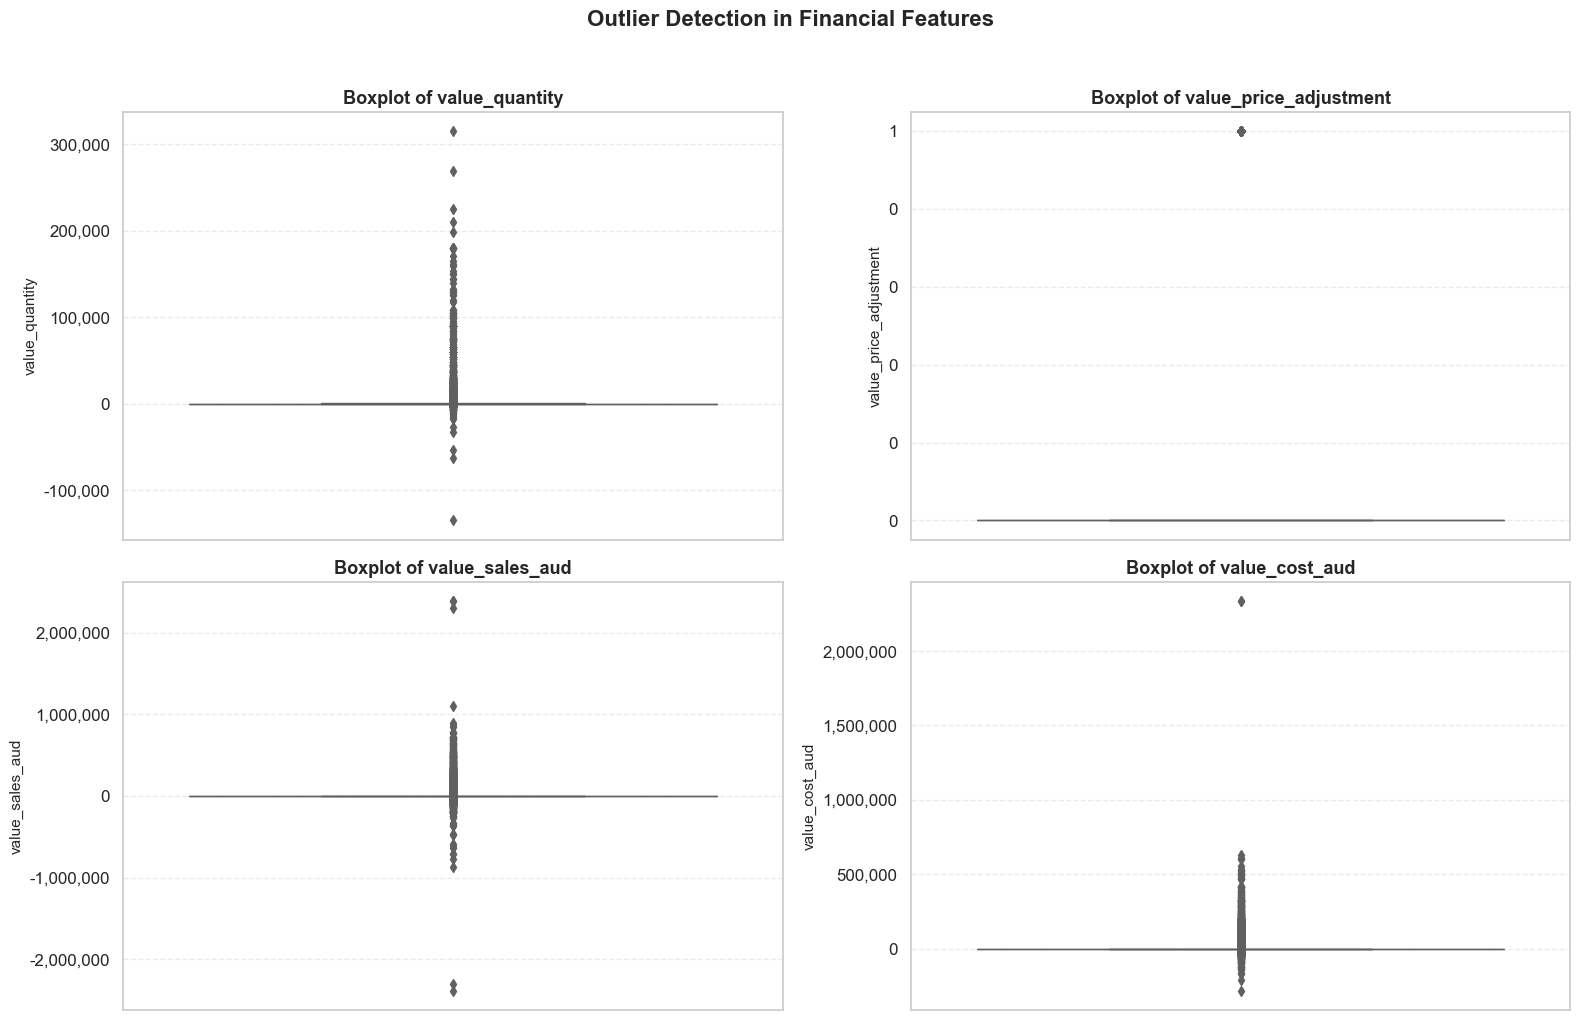

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# Select and clean data
original_cols = ['value_quantity', 'value_price_adjustment', 'value_sales_aud', 'value_cost_aud']
df_box = df[original_cols].dropna()

# Formatter function for thousands separator
def thousands(x, pos):
    return f'{int(x):,}'

# Set plot style
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)
plt.figure(figsize=(16, 10))

# Plot each feature
for i, col in enumerate(original_cols, 1):
    plt.subplot(2, 2, i)
    
    # Check for log-scale
    use_log = (df_box[col] > 0).all() and df_box[col].max() > 1000
    data = np.log1p(df_box[col]) if use_log else df_box[col]
    
    sns.boxplot(y=data, color='#5DADE2', linewidth=1)
    plt.title(f'Boxplot of {col}', fontsize=13, fontweight='bold')
    plt.ylabel(f'{"log1p(" + col + ")" if use_log else col}', fontsize=11)
    
    # Format y-axis ticks with thousands separator (skip if log scale)
    if not use_log:
        plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands))
    
    plt.grid(axis='y', linestyle='--', alpha=0.4)

# Final layout
plt.suptitle('Outlier Detection in Financial Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [191]:
# Apply capping
print("\n=== APPLYING CAPPING ===")
def cap_outliers_percentile(df, column, lower_pct=1, upper_pct=99):
    lower_bound = df[column].quantile(lower_pct/100)
    upper_bound = df[column].quantile(upper_pct/100)
    df[f'{column}_capped'] = df[column].clip(lower_bound, upper_bound)
    outliers_removed = len(df[(df[column] < lower_bound) | (df[column] > upper_bound)])
    print(f" {column}: {outliers_removed} values capped")
    return df

df = cap_outliers_percentile(df, 'value_sales_aud', 1, 99)
df = cap_outliers_percentile(df, 'value_cost_aud', 1, 99)
df = cap_outliers_percentile(df, 'value_quantity', 1, 99)


=== APPLYING CAPPING ===
 value_sales_aud: 39695 values capped
 value_cost_aud: 39630 values capped
 value_quantity: 36982 values capped


In [110]:
# Check skewness after capping
print("\n=== SKEWNESS AFTER CAPPING ===")
print(f"value_sales_aud_capped: {df['value_sales_aud_capped'].skew():.2f}")
print(f"value_cost_aud_capped: {df['value_cost_aud_capped'].skew():.2f}")
print(f"value_quantity_aud_capped: {df['value_quantity_capped'].skew():.2f}")


=== SKEWNESS AFTER CAPPING ===
value_sales_aud_capped: 5.19
value_cost_aud_capped: 5.84
value_quantity_aud_capped: 4.77


In [193]:
# Applying yeojohnson transformation
from scipy.stats import yeojohnson

def apply_yeojohnson(df, columns):
    """Apply Yeo-Johnson transformation to multiple columns"""
    for col in columns:
        # Transform
        df[f'{col}_yeojohnson'], fitted_lambda = yeojohnson(df[f'{col}_capped'])
        
        # Report results
        print(f" {col}:")
        print(f"   Optimal lambda: {fitted_lambda:.3f}")
        print(f"   Transformed skewness: {df[f'{col}_yeojohnson'].skew():.2f}")
        print()
    
    return df

# Apply to multiple columns at once
columns_to_transform = ['value_sales_aud', 'value_cost_aud', 'value_quantity']
df = apply_yeojohnson(df, columns_to_transform)

 value_sales_aud:
   Optimal lambda: 0.788
   Transformed skewness: 1.89

 value_cost_aud:
   Optimal lambda: 0.626
   Transformed skewness: 0.87

 value_quantity:
   Optimal lambda: 0.530
   Transformed skewness: 0.55



To ensure robust statistical inference and improve the interpretability of key financial metrics, we conducted a four-step transformation process targeting extreme outliers and skewed distributions across continuous variables. The variables in focus included value_sales_aud, value_cost_aud, value_quantity, and value_price_adjustment.

**Initial Skewness Check:**

We first computed the skewness of each target variable using df.skew(). The results revealed extreme right-skewness—most notably in value_cost_aud (skewness ≈ 141.36) and value_sales_aud (skewness ≈ 29.89). Such skewness can severely bias regression models and reduce visual clarity.

**Outlier Capping:**

To mitigate the influence of extreme values, we applied percentile-based capping using the 1st and 99th percentiles. This method reduces the impact of rare outliers without removing any rows, preserving data integrity. New capped variables were created (e.g., value_sales_aud_capped) to retain traceability.

**Post-Capping Skewness Check:**

After capping, we re-evaluated the skewness of the transformed variables. While reductions were observed, both value_sales_aud_capped, value_cost_aud_capped and value_quantity_capped remained significantly skewed, indicating that further transformation was required to normalise the distributions.

**Yeo–Johnson Transformation:**

We applied the Yeo–Johnson transformation to the capped variables. Unlike log or Box–Cox methods, Yeo–Johnson accommodates zero and negative values—crucial given that some negative values represent credited adjustments (rather than data errors). 

This validated that the pipeline—capping followed by Yeo–Johnson—successfully normalised the financial metrics, preparing them for downstream analysis such as visualisation, t-tests, and multiple linear regression (MLR).

# Answer Section 2: Exploratory Insights (all the codes in one cell - do not insert extra cells) 

## section 2.1 (all the codes in one cell - do not insert extra cells) 

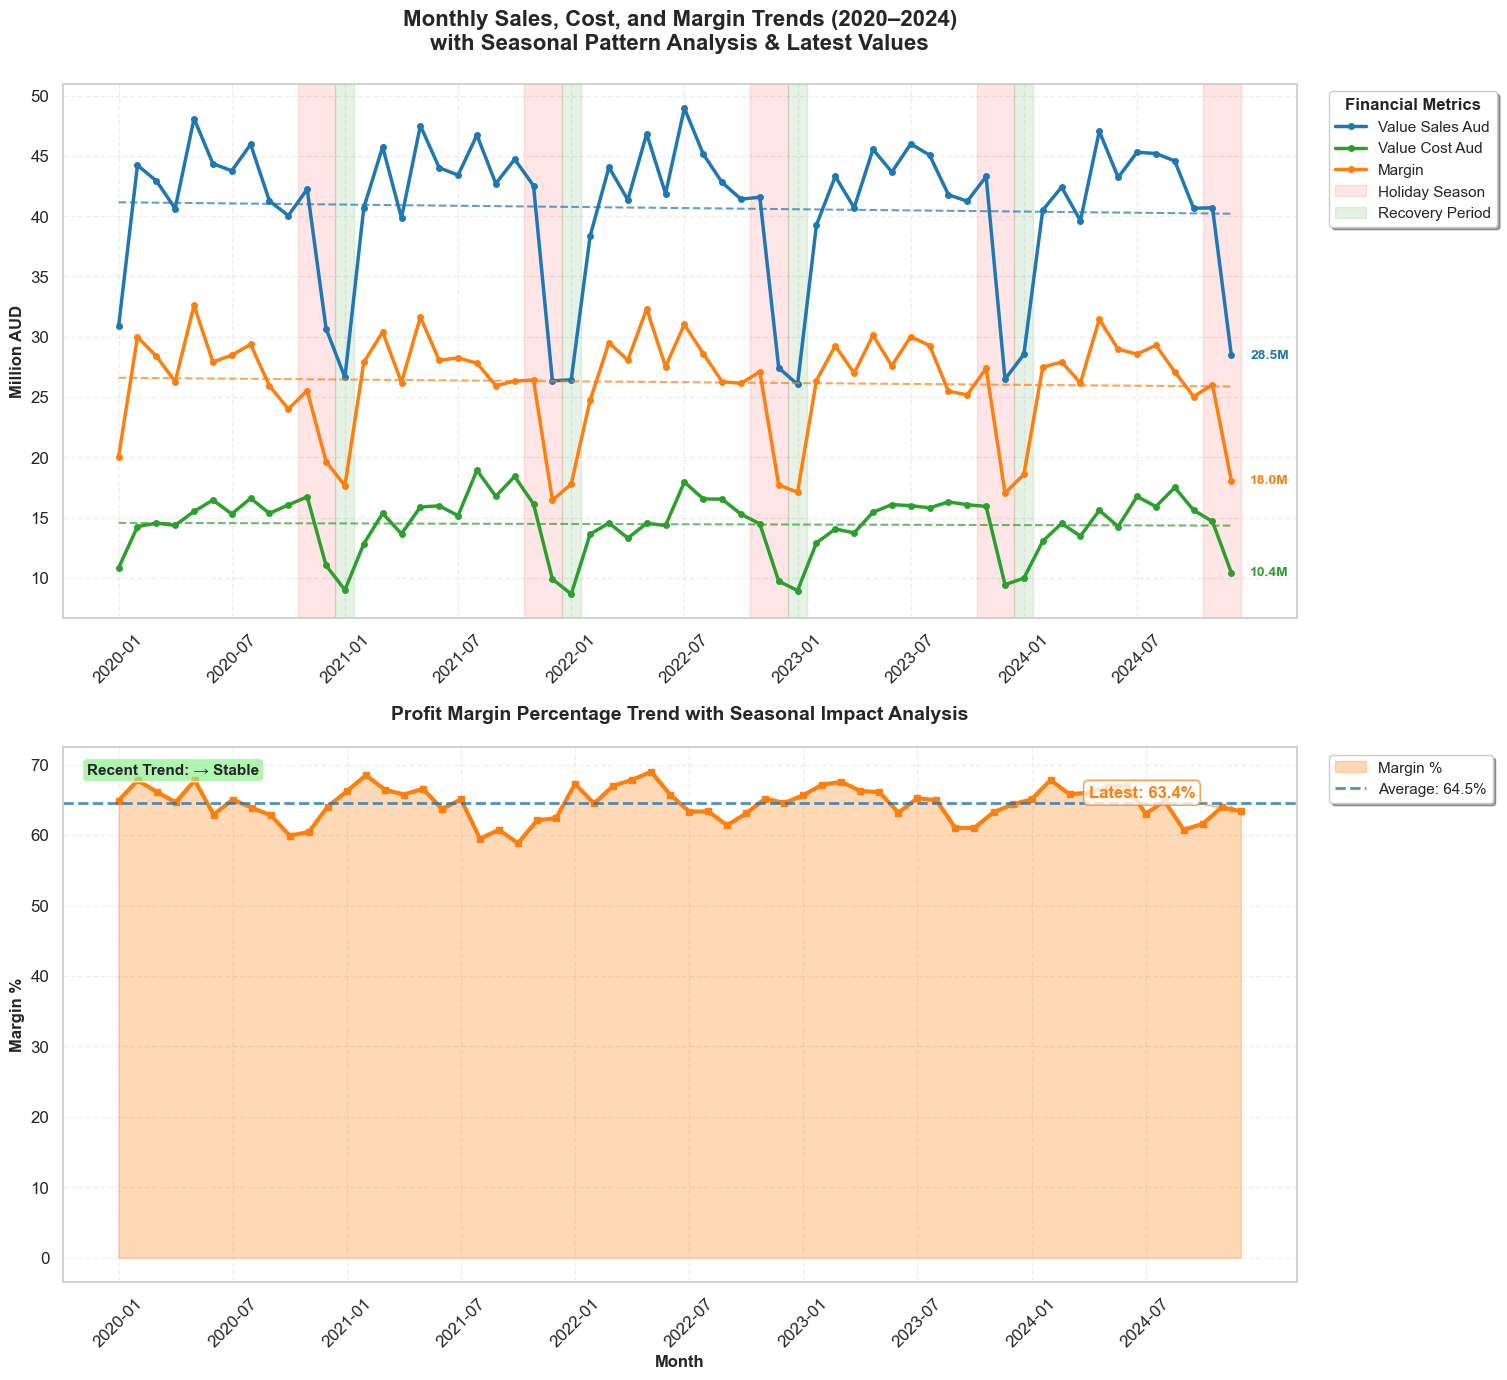

In [196]:
# Enhanced Financial Dashboard with Executive-Ready Improvements
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

# Ensure margin and month columns are present
df['margin'] = df['value_sales_aud'] - df['value_cost_aud']
df['month'] = df['accounting_date'].dt.to_period('M').astype(str)

# Monthly aggregation (in millions)
df_monthly = df.groupby('month')[['value_sales_aud', 'value_cost_aud', 'margin']].sum() / 1e6
df_monthly = df_monthly.sort_index()

# Set up plot with improved spacing
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 14))
colors = ['#1f77b4', '#2ca02c', '#ff7f0e']  # Blue, Green, Orange theme
x_range = range(len(df_monthly))

# Plot 1: Sales, Cost, Margin with trend lines
for i, col in enumerate(['value_sales_aud', 'value_cost_aud', 'margin']):
    # Main line plot
    ax1.plot(x_range, df_monthly[col], color=colors[i], linewidth=2.5, 
             label=col.replace('_', ' ').replace('aud', 'AUD').title(), 
             marker='o', markersize=4)
    
    # Trend line
    z = np.polyfit(x_range, df_monthly[col], 1)
    p = np.poly1d(z)
    ax1.plot(x_range, p(x_range), "--", color=colors[i], alpha=0.7, linewidth=1.5)

# Enhanced seasonal annotations with multiple December/January patterns
seasonal_annotations = []



# Add latest month value annotations for executive summary
latest_idx = len(df_monthly) - 1
for i, col in enumerate(['value_sales_aud', 'value_cost_aud', 'margin']):
    latest_val = df_monthly.iloc[latest_idx][col]
    ax1.annotate(f'{latest_val:.1f}M', 
                xy=(latest_idx, latest_val), 
                xytext=(latest_idx + 1, latest_val),
                fontsize=10, fontweight='bold', color=colors[i],
                ha='left', va='center')

# Shade end-of-year periods for better UX
for year in range(2020, 2025):
    nov_idx = df_monthly.index.get_loc(f'{year}-11') if f'{year}-11' in df_monthly.index else None
    dec_idx = df_monthly.index.get_loc(f'{year}-12') if f'{year}-12' in df_monthly.index else None
    jan_idx = df_monthly.index.get_loc(f'{year+1}-01') if f'{year+1}-01' in df_monthly.index else None
    
    # Shade November-December (holiday season)
    if nov_idx is not None and dec_idx is not None:
        ax1.axvspan(nov_idx - 0.5, dec_idx + 0.5, alpha=0.1, color='red', 
                   label='Holiday Season' if year == 2020 else "")
    
    # Shade January (recovery period)
    if jan_idx is not None:
        ax1.axvspan(jan_idx - 0.5, jan_idx + 0.5, alpha=0.1, color='green', 
                   label='Recovery Period' if year == 2020 else "")

ax1.set_title('Monthly Sales, Cost, and Margin Trends (2020–2024)\nwith Seasonal Pattern Analysis & Latest Values', 
              fontsize=16, fontweight='bold', pad=25)
ax1.set_ylabel('Million AUD', fontsize=12, fontweight='bold')
ax1.set_xticks(range(0, len(df_monthly), 6))
ax1.set_xticklabels([df_monthly.index[i] for i in range(0, len(df_monthly), 6)], rotation=45)

# Enhanced legend positioned outside the plot area
legend1 = ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, 
                     fancybox=True, shadow=True, fontsize=11, 
                     title='Financial Metrics', title_fontsize=12)
legend1.get_title().set_fontweight('bold')

ax1.grid(True, linestyle='--', alpha=0.3)

# Plot 2: Enhanced Margin % with consistent theme colors
df_monthly['margin_pct'] = (df_monthly['margin'] / df_monthly['value_sales_aud']) * 100

# Fill area with theme orange color
ax2.fill_between(x_range, df_monthly['margin_pct'], alpha=0.3, color=colors[2], label='Margin %')
ax2.plot(x_range, df_monthly['margin_pct'], color=colors[2], linewidth=3, marker='s', markersize=5)

# Average line with theme blue color
avg_margin = df_monthly['margin_pct'].mean()
ax2.axhline(y=avg_margin, color=colors[0], linestyle='--', alpha=0.8, linewidth=2,
           label=f'Average: {avg_margin:.1f}%')

# Annotate latest margin percentage with theme orange
latest_margin = df_monthly['margin_pct'].iloc[-1]
ax2.annotate(f'Latest: {latest_margin:.1f}%', 
            xy=(latest_idx, latest_margin), 
            xytext=(latest_idx - 8, latest_margin + 2),
            fontsize=12, fontweight='bold', color=colors[2],
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor=colors[2]),
            arrowprops=dict(arrowstyle='->', color=colors[2], alpha=0.7))


# Add trend indicator with theme green color
margin_trend = np.polyfit(x_range[-6:], df_monthly['margin_pct'].iloc[-6:], 1)[0]  # Last 6 months trend
trend_text = "↗ Improving" if margin_trend > 0.1 else "↘ Declining" if margin_trend < -0.1 else "→ Stable"
ax2.text(0.02, 0.95, f'Recent Trend: {trend_text}', transform=ax2.transAxes, 
         fontsize=11, fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7))



ax2.set_title('Profit Margin Percentage Trend with Seasonal Impact Analysis', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_ylabel('Margin %', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_xticks(range(0, len(df_monthly), 6))
ax2.set_xticklabels([df_monthly.index[i] for i in range(0, len(df_monthly), 6)], rotation=45)

# Enhanced legend positioned outside the plot area
legend2 = ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, 
                     fancybox=True, shadow=True, fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.3)

# Adjust layout to accommodate external legends
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()

## section 2.2 (all the codes in one cell - do not insert extra cells) 

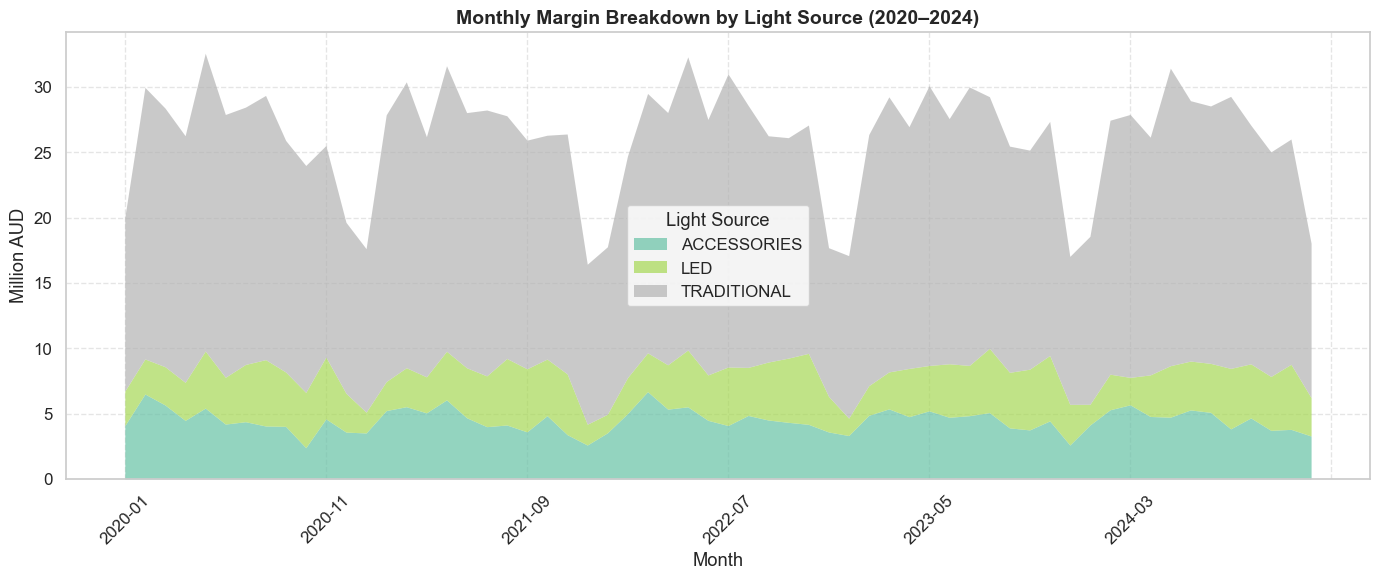

In [198]:
# Aggregate margin by light_source and month
df_by_light = (
    df.groupby(['month', 'light_source'])[['margin']]
    .sum()
    .reset_index()
)
df_light_pivot = df_by_light.pivot(index='month', columns='light_source', values='margin') / 1e6
df_light_pivot = df_light_pivot.sort_index()

# --- Plot 2: Area plot for margin by light source ---
fig, ax = plt.subplots(figsize=(14, 6))
df_light_pivot.plot(
    ax=ax, kind='area', stacked=True, alpha=0.7, cmap='Set2', linewidth=0
)

ax.set_title('Monthly Margin Breakdown by Light Source (2020–2024)', fontsize=14, weight='bold')
ax.set_ylabel('Million AUD')
ax.set_xlabel('Month')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Light Source')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## section 2.3 (all the codes in one cell - do not insert extra cells) 

Creating Plot 1: Bar Chart with Line...


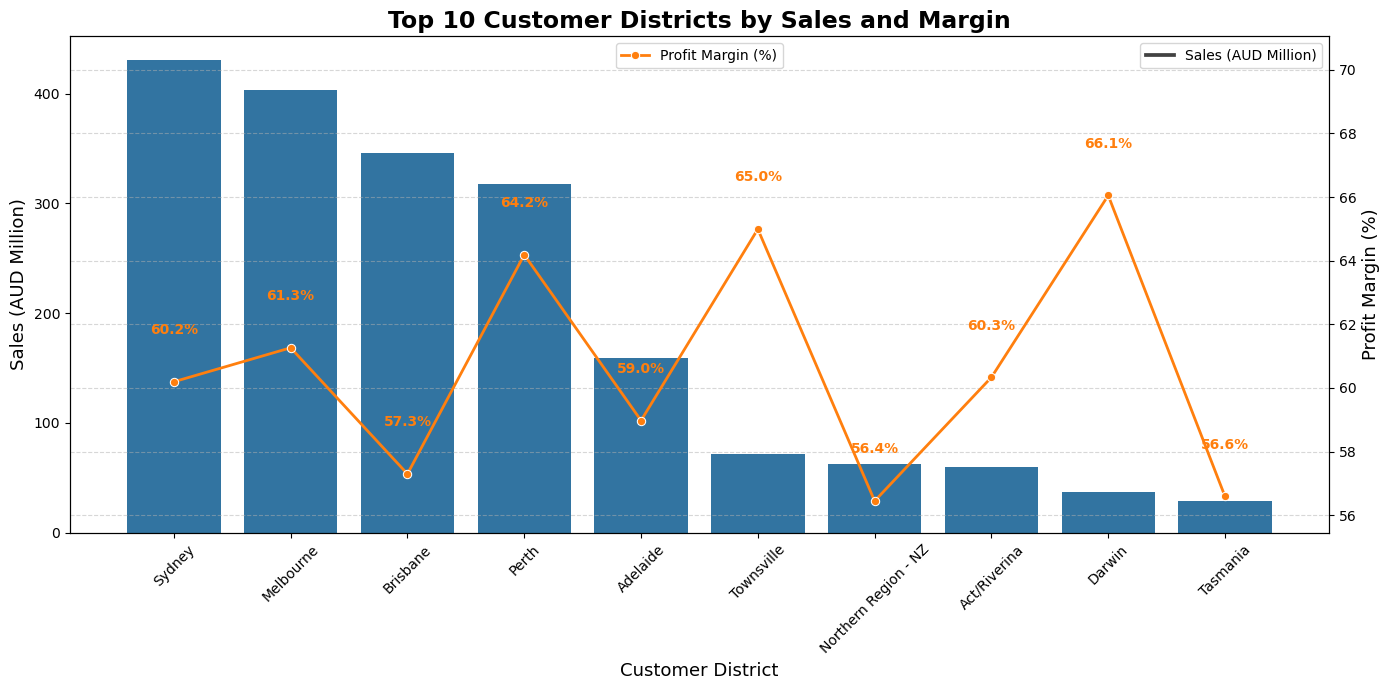

Creating Plot 2: Performance Matrix...


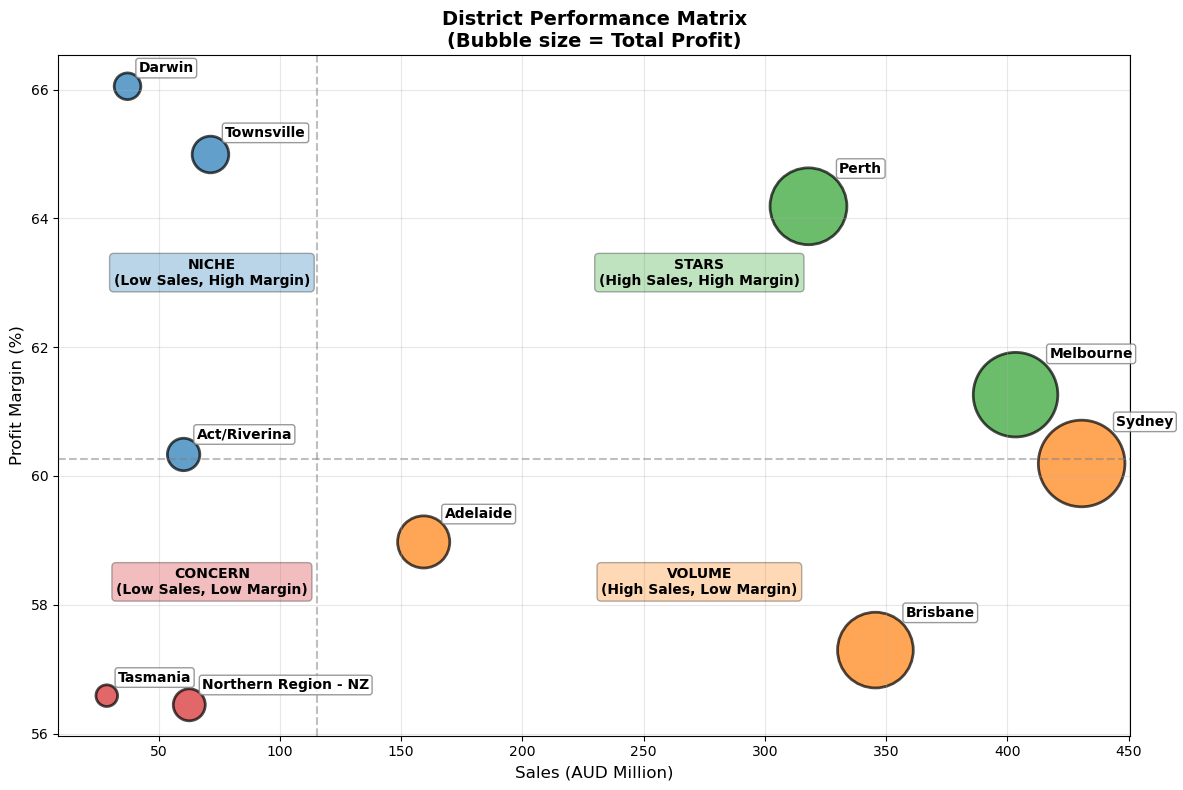

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define district mapping
district_mapping = {
    200: 'Sydney',
    210: 'Act/Riverina',
    300: 'Melbourne',
    310: 'Tasmania',
    400: 'Brisbane',
    410: 'Townsville',
    500: 'Adelaide',
    510: 'Darwin',
    520: 'Inlite - NZ',
    530: 'South Island - NZ',
    535: 'Central Region - NZ',
    540: 'Northern Region - NZ',
    545: 'Head Office NZ',
    600: 'Perth',
    710: 'Head Office Sales',
    720: 'Intercompany Sales'
}

# Bar Chart with Line
print("Creating Plot 1: Bar Chart with Line...")

# Filter and calculate margin
df_valid = df[df['value_sales_aud'] > 0].copy()
df_valid['profit_margin'] = (
    (df_valid['value_sales_aud'] - df_valid['value_cost_aud']) / df_valid['value_sales_aud']
) * 100

# Aggregate 
df_top10_plot1 = df_valid.groupby('customer_district_code', observed=True).agg(
    total_sales=('value_sales_aud', 'sum'),
    avg_margin_pct=('profit_margin', 'mean')
).reset_index()

# Map names & filter out non-regional codes 
df_top10_plot1['district_name'] = df_top10_plot1['customer_district_code'].astype(int).map(district_mapping)
df_top10_plot1 = df_top10_plot1[df_top10_plot1['district_name'].notna()]
df_top10_plot1 = df_top10_plot1[~df_top10_plot1['district_name'].isin(['Intercompany Sales', 'Head Office Sales'])]
df_top10_plot1 = df_top10_plot1.sort_values("total_sales", ascending=False).head(10).reset_index(drop=True)

# Convert to millions for better readability
df_top10_plot1['total_sales_millions'] = df_top10_plot1['total_sales'] / 1_000_000

# Plot settings
bar_color = '#1f77b4'
line_color = '#ff7f0e'

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar plot (sales)
bars = sns.barplot(x='district_name', y='total_sales_millions', data=df_top10_plot1, ax=ax1, color=bar_color)
ax1.set_ylabel("Sales (AUD Million)", fontsize=13)
ax1.set_xlabel("Customer District", fontsize=13)
ax1.tick_params(axis='x', rotation=45)

# Line plot (margin %)
ax2 = ax1.twinx()
sns.lineplot(x='district_name', y='avg_margin_pct', data=df_top10_plot1,
             ax=ax2, color=line_color, marker='o', linewidth=2)
ax2.set_ylabel("Profit Margin (%)", fontsize=13)
ax2.set_ylim(df_top10_plot1['avg_margin_pct'].min() - 1, df_top10_plot1['avg_margin_pct'].max() + 5)

# Label % on line
for idx, row in df_top10_plot1.iterrows():
    ax2.text(idx, row['avg_margin_pct'] + 1.5, f"{row['avg_margin_pct']:.1f}%",
             color=line_color, ha='center', fontsize=10, fontweight='bold')

# Title and layout
plt.title("Top 10 Customer Districts by Sales and Margin", fontsize=17, fontweight='bold')
ax1.legend(['Sales (AUD Million)'], loc='upper right')
ax2.legend(['Profit Margin (%)'], loc='upper center')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# PLOT 2: Performance Matrix
print("Creating Plot 2: Performance Matrix...")

# Filter out rows with zero or negative sales
df_valid_plot2 = df[df['value_sales_aud'] > 0].copy()

# Compute profit margin per row (%)
df_valid_plot2['profit_margin_pct'] = (
    (df_valid_plot2['value_sales_aud'] - df_valid_plot2['value_cost_aud']) / df_valid_plot2['value_sales_aud']
) * 100

# Group by district and aggregate
df_top10_plot2 = df_valid_plot2.groupby('customer_district_code', observed=True).agg(
    sales_total_aud=('value_sales_aud', 'sum'),
    avg_margin_pct=('profit_margin_pct', 'mean')
).reset_index()

# Map district names and filter
df_top10_plot2['district_name'] = df_top10_plot2['customer_district_code'].astype(int).map(district_mapping)
df_top10_plot2 = df_top10_plot2[df_top10_plot2['district_name'].notna()]
df_top10_plot2 = df_top10_plot2[~df_top10_plot2['district_name'].isin(['Intercompany Sales', 'Head Office Sales'])]
df_top10_plot2 = df_top10_plot2.sort_values("sales_total_aud", ascending=False).head(10).reset_index(drop=True)

# Convert sales to millions for readability
df_top10_plot2['sales_millions'] = (df_top10_plot2['sales_total_aud'] / 1_000_000).round(2)

# Compute total profit in millions
df_top10_plot2['profit_millions'] = (df_top10_plot2['sales_millions'] * df_top10_plot2['avg_margin_pct'] / 100).round(2)

# Define theme colors
theme_colors = ['#1f77b4', '#2ca02c', '#ff7f0e']  # Blue, Green, Orange theme

# Set up the plot area
fig, ax = plt.subplots(figsize=(12, 8))

# Median thresholds
sales_median = df_top10_plot2['sales_millions'].median()
margin_median = df_top10_plot2['avg_margin_pct'].median()

# Assign quadrant colors with theme colors
colors = []
for sales, margin in zip(df_top10_plot2['sales_millions'], df_top10_plot2['avg_margin_pct']):
    if sales >= sales_median and margin >= margin_median:
        colors.append(theme_colors[1])  # Green - STARS
    elif sales >= sales_median and margin < margin_median:
        colors.append(theme_colors[2])  # Orange - VOLUME
    elif sales < sales_median and margin >= margin_median:
        colors.append(theme_colors[0])  # Blue - NICHE
    else:
        colors.append('#d62728')        # Red - CONCERN

# Bubble chart
scatter = ax.scatter(
    df_top10_plot2['sales_millions'],
    df_top10_plot2['avg_margin_pct'],
    s=df_top10_plot2['profit_millions'] * 15,
    c=colors,
    alpha=0.7,
    edgecolors='black',
    linewidth=2
)

# Add district labels with better positioning to avoid overlap
for i, txt in enumerate(df_top10_plot2['district_name']):
    # Calculate bubble radius approximation for better positioning
    bubble_size = df_top10_plot2['profit_millions'].iloc[i] * 15
    offset_distance = max(8, (bubble_size ** 0.5) * 0.4)  # Smaller offset to keep labels closer
    
    ax.annotate(txt,
                (df_top10_plot2['sales_millions'].iloc[i], df_top10_plot2['avg_margin_pct'].iloc[i]),
                xytext=(offset_distance, offset_distance), textcoords='offset points',
                fontsize=10, fontweight='bold', color='black',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='gray'),
                ha='left', va='bottom')

# Draw quadrant lines
ax.axvline(x=sales_median, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=margin_median, color='gray', linestyle='--', alpha=0.5)

# Compute min/max for positioning
sales_min, sales_max = df_top10_plot2['sales_millions'].min(), df_top10_plot2['sales_millions'].max()
margin_min, margin_max = df_top10_plot2['avg_margin_pct'].min(), df_top10_plot2['avg_margin_pct'].max()

# Helper to compute midpoint
def midpoint(a, b): 
    return (a + b) / 2

# Label quadrant regions with theme colors
ax.text(midpoint(sales_median, sales_max), midpoint(margin_median, margin_max),
        'STARS\n(High Sales, High Margin)', ha='center', va='center',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor=theme_colors[1], alpha=0.3))

ax.text(midpoint(sales_min, sales_median), midpoint(margin_median, margin_max),
        'NICHE\n(Low Sales, High Margin)', ha='center', va='center',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor=theme_colors[0], alpha=0.3))

ax.text(midpoint(sales_median, sales_max), midpoint(margin_min, margin_median),
        'VOLUME\n(High Sales, Low Margin)', ha='center', va='center',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor=theme_colors[2], alpha=0.3))

ax.text(midpoint(sales_min, sales_median), midpoint(margin_min, margin_median),
        'CONCERN\n(Low Sales, Low Margin)', ha='center', va='center',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='#d62728', alpha=0.3))

# Axis labels and title
ax.set_xlabel('Sales (AUD Million)', fontsize=12)
ax.set_ylabel('Profit Margin (%)', fontsize=12)
ax.set_title('District Performance Matrix\n(Bubble size = Total Profit)',
             fontsize=14, fontweight='bold')

# Axis padding
x_pad = (sales_max - sales_min) * 0.05
y_pad = (margin_max - margin_min) * 0.05
ax.set_xlim(sales_min - x_pad, sales_max + x_pad)
ax.set_ylim(margin_min - y_pad, margin_max + y_pad)

# Grid and layout
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## section 2.4 (all the codes in one cell - do not insert extra cells) 

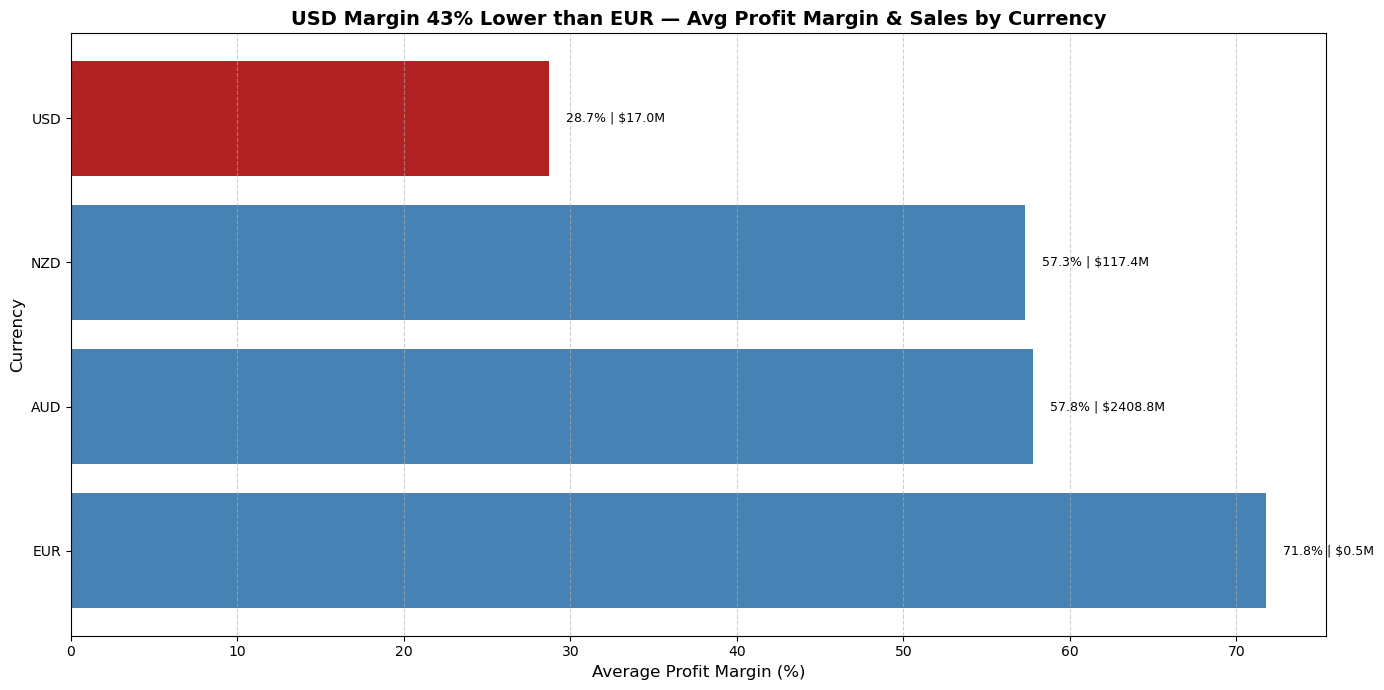

In [156]:
# Filter and calculate profit margin using transformed variables 
df_valid = df[df['value_sales_aud'] > 0].copy()
df_valid['profit_margin'] = (
    (df_valid['value_sales_aud'] - df_valid['value_cost_aud']) / df_valid['value_sales_aud']
) * 100

# Group by currency: average margin, transaction count, and total sales
currency_stats = df_valid.groupby('currency').agg({
    'profit_margin': 'mean',
    'value_sales_aud': 'sum',
    'currency': 'count'
}).rename(columns={
    'profit_margin': 'avg_profit_margin',
    'value_sales_aud': 'total_sales',
    'currency': 'transaction_count'
}).reset_index()

# Convert sales to millions
currency_stats['total_sales_million'] = currency_stats['total_sales'] / 1e6
currency_stats = currency_stats.sort_values('avg_profit_margin', ascending=False)

# Highlight lowest margin currency
highlight_currency = currency_stats.iloc[-1]['currency']
colors = ['firebrick' if c == highlight_currency else 'steelblue' for c in currency_stats['currency']]

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(currency_stats['currency'], currency_stats['avg_profit_margin'], color=colors)

# Add profit margin and sales labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    sales = currency_stats.iloc[i]['total_sales_million']
    label = f'{width:.1f}% | ${sales:.1f}M'
    ax.text(width + 1, bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=9)

# Titles and axis labels
ax.set_title('USD Margin 43% Lower than EUR — Avg Profit Margin & Sales by Currency',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Profit Margin (%)', fontsize=12)
ax.set_ylabel('Currency', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## section 2.5 (all the codes in one cell - do not insert extra cells) 

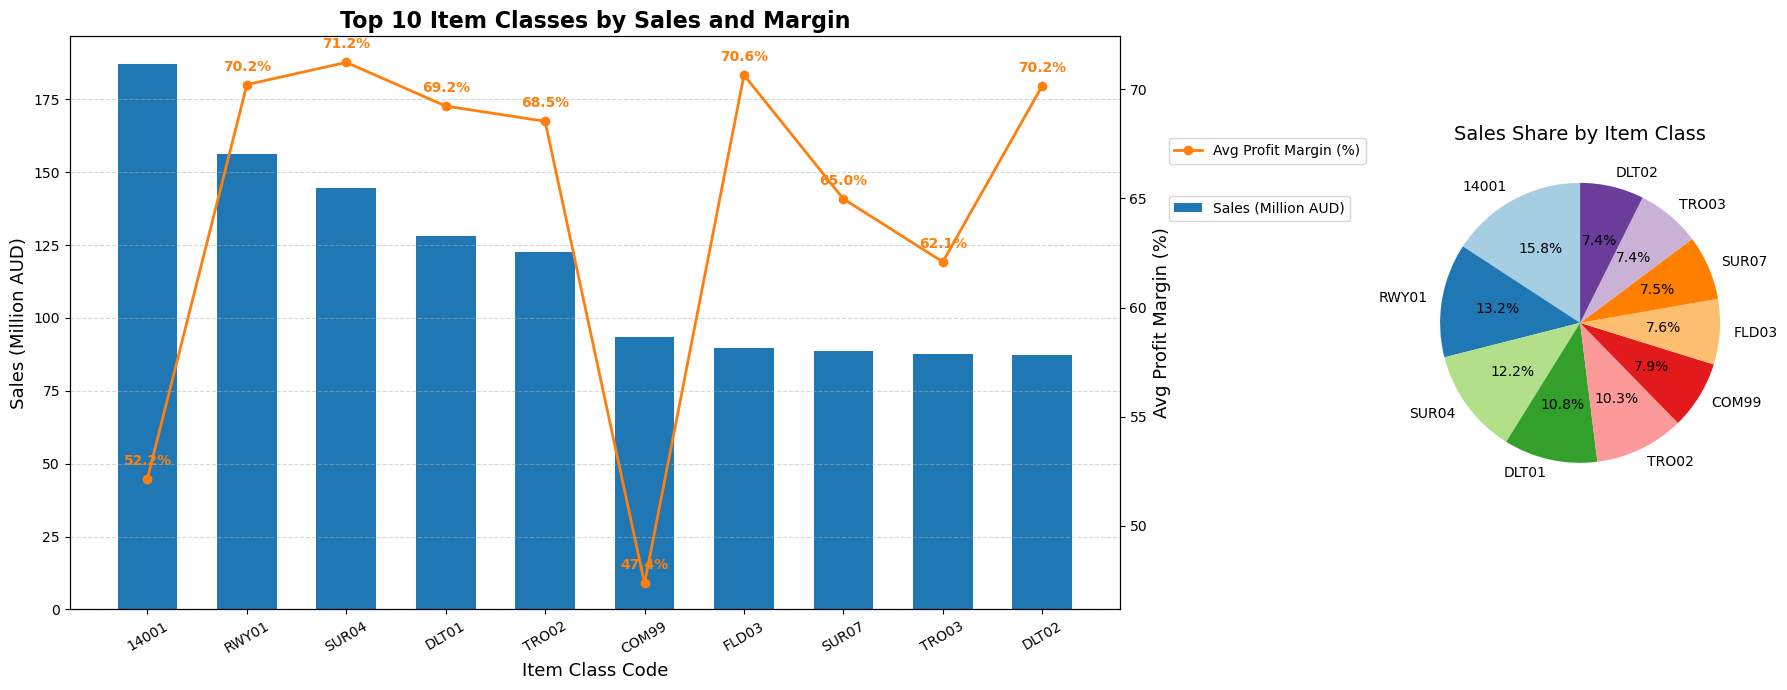

In [158]:
import matplotlib.pyplot as plt

# Filter and calculate profit margin using transformed variables
df_valid = df[df['value_sales_aud'] > 0].copy()
df_valid['profit_margin'] = (
    (df_valid['value_sales_aud'] - df_valid['value_cost_aud']) / df_valid['value_sales_aud']
) * 100

# Aggregate sales and average margin per item class
class_perf = df_valid.groupby('item_class_code', observed=True).agg({
    'value_sales_aud': lambda x: x.sum() / 1e6,  # millions
    'profit_margin': 'mean'
}).reset_index().rename(columns={
    'value_sales_aud': 'total_sales_million',
    'profit_margin': 'avg_margin'
})

# Select top 10 classes by sales
top_classes = class_perf.sort_values(by='total_sales_million', ascending=False).head(10)

# Plot both combo chart and pie chart
fig, (ax1, ax_pie) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [3, 1]})

bar_color = '#1f77b4'
line_color = '#ff7f0e'

# Combo chart (bar + line)
bars = ax1.bar(
    top_classes['item_class_code'],
    top_classes['total_sales_million'],
    color=bar_color,
    label='Sales (Million AUD)',
    width=0.6
)
ax1.set_ylabel('Sales (Million AUD)', fontsize=13)
ax1.set_xlabel('Item Class Code', fontsize=13)
ax1.tick_params(axis='x', rotation=30)

# Line chart on twin axis
ax2 = ax1.twinx()
ax2.plot(
    top_classes['item_class_code'],
    top_classes['avg_margin'],
    color=line_color,
    marker='o',
    label='Avg Profit Margin (%)',
    linewidth=2
)
ax2.set_ylabel('Avg Profit Margin (%)', fontsize=13)

# Annotate points
for x, y in zip(top_classes['item_class_code'], top_classes['avg_margin']):
    ax2.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 10),
                 textcoords='offset points', ha='center',
                 fontsize=10, color=line_color, fontweight='bold')

# Title and legends (outside right)
ax1.set_title('Top 10 Item Classes by Sales and Margin', fontsize=16, fontweight='bold')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# Move legends outside
ax1.legend(loc='center left', bbox_to_anchor=(1.04, 0.7))
ax2.legend(loc='center left', bbox_to_anchor=(1.04, 0.8))

# Pie chart
ax_pie.pie(
    top_classes['total_sales_million'],
    labels=top_classes['item_class_code'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Paired.colors[:10]
)
ax_pie.set_title('Sales Share by Item Class', fontsize=14)

plt.tight_layout()
plt.show()


# Answer to Section 3: Test Sub Sample Differences (all the codes in one cell - do not insert extra cells) 

## section 3.1 (all the codes in one cell - do not insert extra cells) 

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, yeojohnson, skew

# 1. Calculate raw profit margin
df['margin'] = df['value_sales_aud'] - df['value_cost_aud']

# 2. Check skewness and transform if |skew| > 0.5
margin_skew = skew(df['margin'].dropna())
print(f"Original margin skewness: {margin_skew:.4f}")

if abs(margin_skew) > 0.5:
    print("Applying Yeo-Johnson transformation due to high skewness")
    # Transform only non-null margins and align back correctly
    non_null_margin = df['margin'].dropna()
    transformed_margin, _ = yeojohnson(non_null_margin)
    df.loc[non_null_margin.index, 'margin_transformed'] = transformed_margin
    target_col = 'margin_transformed'
else:
    print("Using original margin data (skewness within acceptable range)")
    target_col = 'margin'

# 3. Define region groups
df['customer_district_code'] = df['customer_district_code'].astype(str)
metro_codes = ['200', '300', '400', '500', '600']
regional_codes = ['210', '310', '410', '510']

# 4. Extract transformed/raw margins
metro_margins = df[df['customer_district_code'].isin(metro_codes)][target_col].dropna()
regional_margins = df[df['customer_district_code'].isin(regional_codes)][target_col].dropna()

if len(metro_margins) < 30 or len(regional_margins) < 30:
    print("Warning: One or both groups have <30 samples. Interpret results with caution.")

# 5. Run Welch's t-test (unequal variances assumed)
t_stat, p_val = ttest_ind(metro_margins, regional_margins, equal_var=False)

# 6. Output hypothesis and test results
print("\nQUESTION: Do Metro and Regional customers differ in their average profit margins?")
print("\nHYPOTHESES:")
print("H0: The mean profit margins are equal between Metro and Regional groups.")
print("H1: The mean profit margins are different between Metro and Regional groups.")

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}\n")

# 7. Interpretation
if p_val < 0.05:
    print("CONCLUSION: The result is statistically significant (p < 0.05).")
    print("Average margins differ between Metro and Regional customers.")
    print("This suggests regional pricing, sales strategies, or logistics costs may impact profitability.")
else:
    print("CONCLUSION: The result is not statistically significant (p ≥ 0.05).")
    print("There is no strong evidence of a margin difference between Metro and Regional groups.")


Original margin skewness: -3.3247
Applying Yeo-Johnson transformation due to high skewness

QUESTION: Do Metro and Regional customers differ in their average profit margins?

HYPOTHESES:
H0: The mean profit margins are equal between Metro and Regional groups.
H1: The mean profit margins are different between Metro and Regional groups.

T-Statistic: 3.1989
P-Value: 0.0014

CONCLUSION: The result is statistically significant (p < 0.05).
Average margins differ between Metro and Regional customers.
This suggests regional pricing, sales strategies, or logistics costs may impact profitability.


## section 3.2 (all the codes in one cell - do not insert extra cells) 

In [163]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# MANAGEMENT QUESTION
print("QUESTION: Do Project Orders (PRO) deliver significantly higher profit margins than Credit Project Price Only (CRP) orders?\n")

# HYPOTHESIS
print("HYPOTHESES:")
print("H₀ (Null): The mean profit margin is equal between PRO and CRP orders.")
print("H₁ (Alternative): The mean profit margin is different between PRO and CRP orders.\n")

# STEP 1: Filter for only PRO and CRP order types
df_filtered = df[df['order_type_code'].isin(['PRO', 'CRP'])].copy()

# STEP 2: Extract margin_transformed (assumed pre-calculated)
pro_margin = df_filtered[df_filtered['order_type_code'] == 'PRO']['margin_transformed'].dropna()
crp_margin = df_filtered[df_filtered['order_type_code'] == 'CRP']['margin_transformed'].dropna()

if len(pro_margin) < 30 or len(crp_margin) < 30:
    print("Warning: One or both groups have <30 samples. Interpret results with caution.")

# STEP 3: Run Welch’s t-test (unequal variance)
t_stat, p_val = ttest_ind(pro_margin, crp_margin, equal_var=False)

# STEP 4: Output test statistics
print("T-TEST RESULTS:")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}\n")

# STEP 5: Interpretation
print("CONCLUSION:")
if p_val < 0.05:
    print(" STATISTICALLY SIGNIFICANT DIFFERENCE (p < 0.05)")
    print("→ PRO and CRP orders have significantly different average margins.")
    print("→ This supports the hypothesis that CRP orders may erode profitability compared to PRO.")
else:
    print(" NO STATISTICALLY SIGNIFICANT DIFFERENCE (p ≥ 0.05)")
    print("→ There is no strong evidence of a margin difference between PRO and CRP orders.")


QUESTION: Do Project Orders (PRO) deliver significantly higher profit margins than Credit Project Price Only (CRP) orders?

HYPOTHESES:
H₀ (Null): The mean profit margin is equal between PRO and CRP orders.
H₁ (Alternative): The mean profit margin is different between PRO and CRP orders.

T-TEST RESULTS:
T-Statistic: 11.7546
P-Value: 0.0000

CONCLUSION:
 STATISTICALLY SIGNIFICANT DIFFERENCE (p < 0.05)
→ PRO and CRP orders have significantly different average margins.
→ This supports the hypothesis that CRP orders may erode profitability compared to PRO.


## section 3.3 (all the codes in one cell - do not insert extra cells) 

In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# BUSINESS QUESTION
print("QUESTION: Do LED light source products generate significantly different sales than Traditional light source products?\n")

# HYPOTHESES
print("HYPOTHESES:")
print("H₀ (Null): The mean sales values are equal between LED and Traditional light sources.")
print("H₁ (Alternative): The mean sales values are different between the two light source types.\n")

# STEP 1: Filter only LED and TRADITIONAL products
df_ttest = df[df['light_source'].isin(['LED', 'TRADITIONAL'])].copy()

# STEP 2: Extract transformed sales values
led_sales = df_ttest[df_ttest['light_source'] == 'LED']['value_sales_aud_yeojohnson'].dropna()
trad_sales = df_ttest[df_ttest['light_source'] == 'TRADITIONAL']['value_sales_aud_yeojohnson'].dropna()

if len(led_sales) < 30 or len(trad_sales) < 30:
    print("Warning: One or both groups have <30 samples. Interpret results with caution.")

# STEP 3: Run Welch’s t-test (assumes unequal variances)
t_stat, p_value = ttest_ind(led_sales, trad_sales, equal_var=False)

# STEP 4: Output results
print("T-TEST RESULTS:")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}\n")

# STEP 5: Interpretation
print("CONCLUSION:")
if p_value < 0.05:
    print(" STATISTICALLY SIGNIFICANT DIFFERENCE (p < 0.05)")
    print("→ Sales performance differs between LED and Traditional light sources.")
    print("→ This suggests that lighting technology may influence customer demand or order value.")
else:
    print(" NO STATISTICALLY SIGNIFICANT DIFFERENCE (p ≥ 0.05)")
    print("→ There is no strong evidence of a difference in sales between LED and Traditional light sources.")


QUESTION: Do LED light source products generate significantly different sales than Traditional light source products?

HYPOTHESES:
H₀ (Null): The mean sales values are equal between LED and Traditional light sources.
H₁ (Alternative): The mean sales values are different between the two light source types.

T-TEST RESULTS:
T-Statistic: 54.8587
P-Value: 0.0000

CONCLUSION:
 STATISTICALLY SIGNIFICANT DIFFERENCE (p < 0.05)
→ Sales performance differs between LED and Traditional light sources.
→ This suggests that lighting technology may influence customer demand or order value.


# Answer to Section 4: Inference (all the codes in one cell - do not insert extra cells) 

## section 4.1 (all the codes in one cell - do not insert extra cells)

                               OLS Regression Results                              
Dep. Variable:     total_sales_transformed   R-squared:                       0.597
Model:                                 OLS   Adj. R-squared:                  0.597
Method:                      Least Squares   F-statistic:                     890.2
Date:                     Wed, 04 Jun 2025   Prob (F-statistic):               0.00
Time:                             22:17:05   Log-Likelihood:                -4230.0
No. Observations:                     4387   AIC:                             8470.
Df Residuals:                         4382   BIC:                             8502.
Df Model:                                4                                         
Covariance Type:                       HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

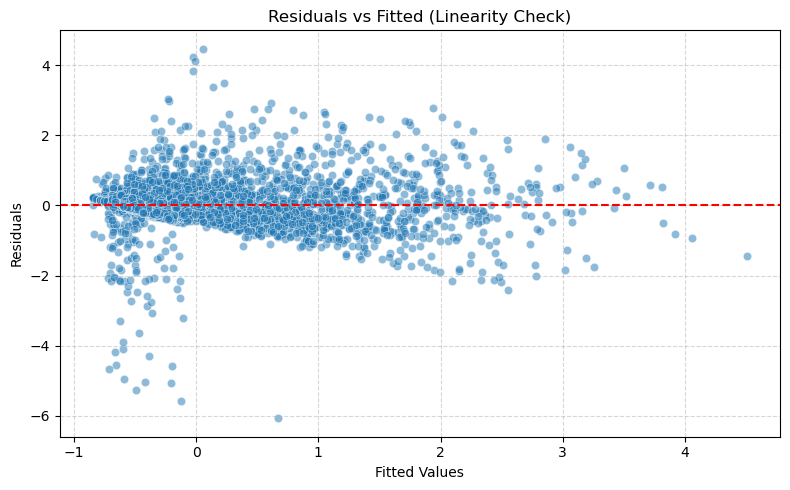

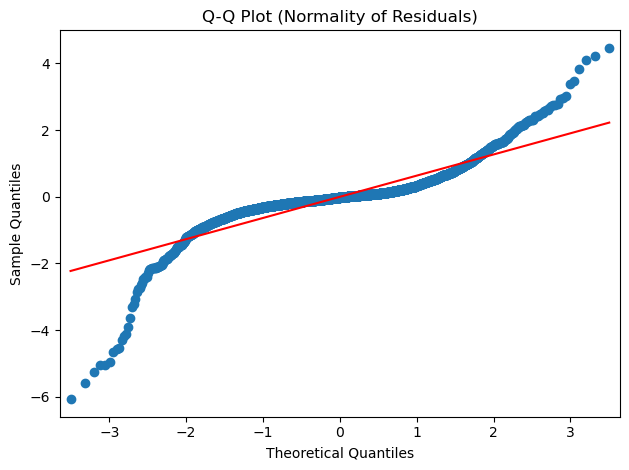


Shapiro-Wilk Test: Statistic = 0.7906, p-value = 0.0000
Durbin-Watson Statistic: 1.7019
Breusch–Pagan Test p-value: 0.0000

=== VIF ===
             Feature       VIF
0              const  1.000000
1  item_type_encoded  1.000719
2   district_encoded  1.036168
3  transaction_count  2.102030
4         tx_squared  2.051017


In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

# --- 1. Feature Engineering ---
df['transaction_count'] = df.groupby('customer_code')['value_sales_aud_yeojohnson'].transform('count')

df_customer = df.groupby('customer_code').agg(
    total_sales=('value_sales_aud_yeojohnson', 'sum'),
    item_type=('item_type', 'first'),
    customer_district_code=('customer_district_code', 'first'),
    transaction_count=('value_sales_aud_yeojohnson', 'count')
).reset_index()

# --- 2. Encode Categorical Features ---
df_customer['item_type_encoded'] = LabelEncoder().fit_transform(df_customer['item_type'].astype(str))
df_customer['district_encoded'] = LabelEncoder().fit_transform(df_customer['customer_district_code'].astype(str))

# --- 3. Outlier Removal ---
q1, q99 = df_customer['total_sales'].quantile([0.01, 0.99])
df_filtered = df_customer[(df_customer['total_sales'] >= q1) & (df_customer['total_sales'] <= q99)]

df_filtered = df_filtered.copy()  # <- Make a copy BEFORE modifying

# --- 4. Yeo-Johnson Transform on y ---
pt = PowerTransformer(method='yeo-johnson')
df_filtered['total_sales_transformed'] = pt.fit_transform(df_filtered[['total_sales']])

# --- 5. Add Polynomial Term ---
df_filtered['tx_squared'] = df_filtered['transaction_count'] ** 2

# --- 6. Define X and y ---
X_raw = df_filtered[['item_type_encoded', 'district_encoded', 'transaction_count', 'tx_squared']]
y = df_filtered['total_sales_transformed']

# --- 7. Scale Features ---
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)
X_scaled = sm.add_constant(X_scaled)
X_scaled = X_scaled.reset_index(drop=True)
y = y.reset_index(drop=True)

# --- 8. Fit OLS Model with Robust SE ---
model = sm.OLS(y, X_scaled)
result = model.fit(cov_type='HC3')
print(result.summary())

# --- 9. Residual Diagnostics ---
residuals = result.resid
fitted = result.fittedvalues

# Linearity Check
plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (Linearity Check)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Normality
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot (Normality of Residuals)")
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = shapiro(residuals)
print(f"\nShapiro-Wilk Test: Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

# Independence
dw = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw:.4f}")

# Homoscedasticity
bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, X_scaled)
print(f"Breusch–Pagan Test p-value: {bp_pval:.4f}")

# Multicollinearity
vif_data = pd.DataFrame({
    'Feature': X_scaled.columns,
    'VIF': [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
})
print("\n=== VIF ===")
print(vif_data)


## section 4.2 (all the codes in one cell - do not insert extra cells)

                            OLS Regression Results                            
Dep. Variable:     margin_transformed   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                 4.126e+04
Date:                Wed, 04 Jun 2025   Prob (F-statistic):               0.00
Time:                        22:17:16   Log-Likelihood:            -1.5581e+07
No. Observations:             1945437   AIC:                         3.116e+07
Df Residuals:                 1945432   BIC:                         3.116e+07
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

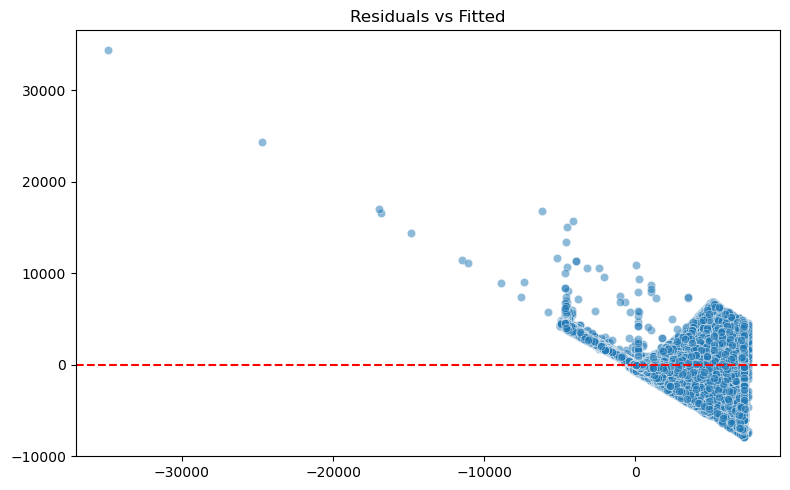

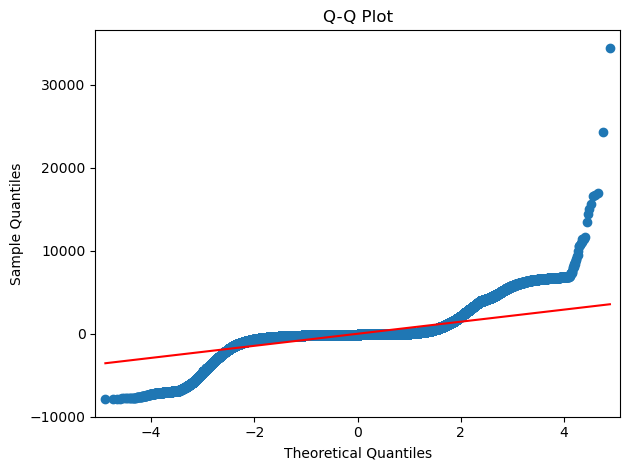


Shapiro-Wilk Test: Statistic = 0.4678, p-value = 0.0000
Durbin-Watson Statistic: 1.3977
Breusch–Pagan Test p-value: 0.0000

=== VIF ===
                      Feature       VIF
0                       const  1.000000
1              value_quantity  1.021700
2         order_type_code_enc  1.081569
3            accounting_month  1.000175
4  value_sales_aud_yeojohnson  1.103564


In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

# --- 1. Filter relevant variables ---
df_txn = df[[
    'margin_transformed', 'value_quantity', 'order_type_code',
    'accounting_month', 'value_sales_aud_yeojohnson'
]].dropna()

# --- 2. Encode order_type_code ---
df_txn['order_type_code_enc'] = LabelEncoder().fit_transform(df_txn['order_type_code'].astype(str))

# --- 3. Clip margin outliers ---
q1, q99 = df_txn['margin_transformed'].quantile([0.01, 0.99])
df_filtered = df_txn[
    (df_txn['margin_transformed'] >= q1) & 
    (df_txn['margin_transformed'] <= q99)
].copy()

# --- 4. Define X and y ---
X = df_filtered[[
    'value_quantity', 'order_type_code_enc', 
    'accounting_month', 'value_sales_aud_yeojohnson'
]]
y = df_filtered['margin_transformed']

# --- 5. Scale and fit OLS model ---
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)
X_scaled = sm.add_constant(X_scaled)
y = y.loc[X_scaled.index]

model = sm.OLS(y, X_scaled)
result = model.fit(cov_type='HC3')
print(result.summary())

# --- 6. Diagnostics ---
residuals = result.resid
fitted = result.fittedvalues

# Residuals vs Fitted
plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

# Q-Q Plot
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot")
plt.tight_layout()
plt.show()

# Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(residuals)
print(f"\nShapiro-Wilk Test: Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

# Durbin-Watson
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw_stat:.4f}")

# Breusch–Pagan
bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, X_scaled)
print(f"Breusch–Pagan Test p-value: {bp_pval:.4f}")

# VIF
vif_data = pd.DataFrame({
    'Feature': X_scaled.columns,
    'VIF': [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
})
print("\n=== VIF ===")
print(vif_data)


## section 4.3 (all the codes in one cell - do not insert extra cells)

                            OLS Regression Results                            
Dep. Variable:      transaction_count   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     295.7
Date:                Wed, 04 Jun 2025   Prob (F-statistic):          6.22e-226
Time:                        22:17:31   Log-Likelihood:                -31072.
No. Observations:                4477   AIC:                         6.215e+04
Df Residuals:                    4472   BIC:                         6.219e+04
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

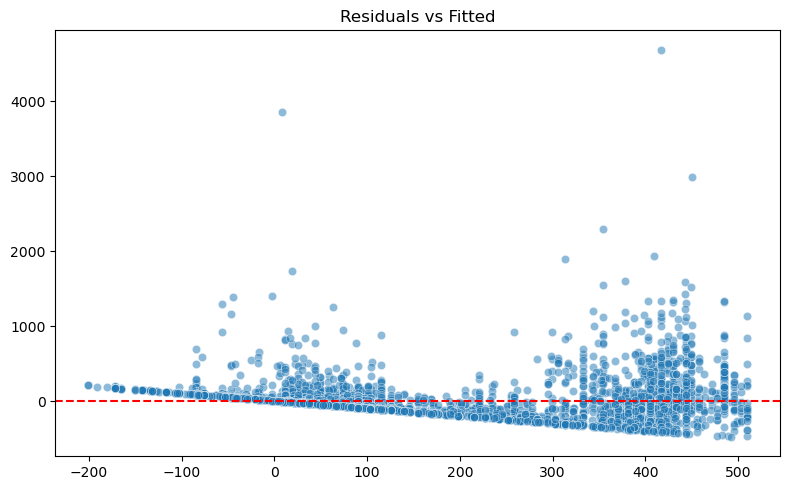

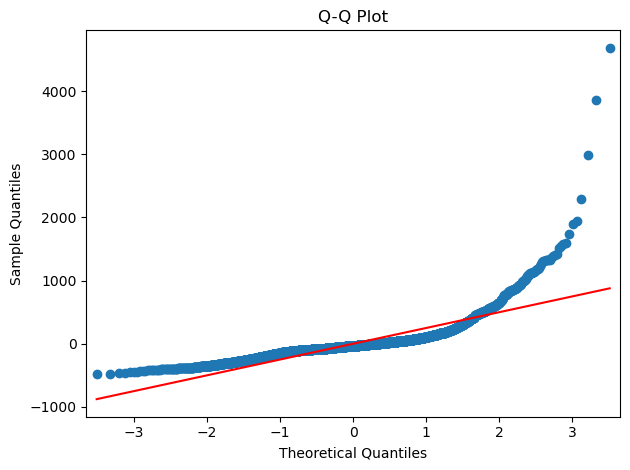


Shapiro-Wilk Test: Statistic = 0.6994, p-value = 0.0000
Durbin-Watson Statistic: 1.5901
Breusch–Pagan Test p-value: 0.0000

=== VIF ===
                      Feature       VIF
0                       const  1.000000
1  customer_district_code_enc  1.110359
2  business_chain_l1_code_enc  1.017858
3        bonus_group_code_enc  1.127118
4        abc_class_volume_enc  1.133499


In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

# --- 1. Aggregate transaction count per customer ---
df_txn = df.copy()
df_txn['transaction_count'] = df_txn.groupby('customer_code')['invoice_number'].transform('nunique')

# --- 2. Filter relevant variables ---
df_model = df_txn[[
    'customer_code', 'transaction_count',
    'customer_district_code', 'business_chain_l1_code',
    'bonus_group_code', 'abc_class_volume'
]].dropna()

# Drop duplicates to keep one record per customer
df_model = df_model.drop_duplicates(subset='customer_code').copy()

# --- 3. Encode categorical variables ---
label_cols = ['customer_district_code', 'business_chain_l1_code', 'bonus_group_code', 'abc_class_volume']
for col in label_cols:
    df_model[col + '_enc'] = LabelEncoder().fit_transform(df_model[col].astype(str))

# --- 4. Define X and y ---
X = df_model[[
    'customer_district_code_enc', 'business_chain_l1_code_enc',
    'bonus_group_code_enc', 'abc_class_volume_enc'
]]
y = df_model['transaction_count']

# --- 5. Scale and fit OLS model ---
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)
X_scaled = sm.add_constant(X_scaled)
y = y.loc[X_scaled.index]

model = sm.OLS(y, X_scaled)
result = model.fit(cov_type='HC3')
print(result.summary())

# --- 6. Diagnostics ---
residuals = result.resid
fitted = result.fittedvalues

# Residuals vs Fitted
plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

# Q-Q Plot
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot")
plt.tight_layout()
plt.show()

# Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(residuals)
print(f"\nShapiro-Wilk Test: Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

# Durbin-Watson
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw_stat:.4f}")

# Breusch–Pagan
bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, X_scaled)
print(f"Breusch–Pagan Test p-value: {bp_pval:.4f}")

# VIF
vif_data = pd.DataFrame({
    'Feature': X_scaled.columns,
    'VIF': [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
})
print("\n=== VIF ===")
print(vif_data)
